#**TFM - FEATURES&MODEL - Clasificación automática de residuos industriales**

##**1. DESCRIPCIÓN Y OBJETIVO**

### **1.1. Objeto**

Este proyecto tiene como objetivo desarrollar e implementar la clasificación automática de residuos industriales sólidos en imágenes reales utilizando el dataset *RealWaste* del repositorio UCI Machine Learning.

Se plantean tres escenarios de resolución:
 - **Enfoque A.** Extracción de características en base al color y textura e implementación de modelos Machine Learning clásicos
 - **Enfoque B.** Desarrollo Deep Learning mediante red neuronal CNN preentrenada
 - **Enfoque C.** Red neuronal CNN preentrenada como Feature Extractor y entrenamiento con modelos clásicos ML

Esto nos permitirá comparar interpretabilidad, rendimiento y requerimientos de los datos así como observar la mejora que obtenemos al aplicar un enfoque híbrido implementando metodologías propias tanto de Machine Learning como Deep Learning.

### **1.2. Antecedentes**

La gestión de residuos urbanos representa uno de los desafíos medioambeintales más relevantes de la actualidad. La clasificación manual de materiales reciclables es un proceso costoso, lento y propenso comunmente a errores humanos. En los últimos años, la visión por computador y el aprendizaje profundo han mostrado un gran potencial para automatizar este proceso pero a su vez significan un reto el cual hay que tratar de optimizar.

El dataset a utilizar presenta imágenes capturadas en entornos reales frente a variaciones de iluminación, fondo y orientación, lo cual se convierte en un banco de pruebas ideal para evaluar modelos robustos.


###**1.3. Carga del dataset**


In [ ]:
!pip install tensorflow

In [ ]:
#Importación de librerías
#importación de librerías
import cv2
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [ ]:
#Descarga de archivo zip
!curl -k -O https://archive.ics.uci.edu/static/public/908/realwaste.zip

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  656M    0  656M    0     0  17.4M      0 --:--:--  0:00:37 --:--:-- 17.0M


In [ ]:
#Descomprimir archivo zip
!unzip -oq realwaste.zip
!ls

realwaste-main	realwaste.zip  sample_data


Al descomprimir tenemos la carpeta 'realwaste-main' que contiene la carpeta 'RealWaste' y un archivo README.md.

In [ ]:
#Vemos si dentro de RealWaste se encuentran las subcarpetas deseadas
!ls realwaste-main/RealWaste

 Cardboard	  Glass  'Miscellaneous Trash'	 Plastic	  Vegetation
'Food Organics'   Metal   Paper			'Textile Trash'


## **3. Train/validation/test split**

Para una mejor organización, agruparemos en 3 carpetas las imágenes destinadas a entrenamiento, evaluación y test. Para ello, en el directorio existente 'realwaste-main', crearemos otra carpeta llamada 'Split-RealWaste' que contenga a su vez las carpetas de train, validation y test con el número de imágenes correspondiente:
70%, 15% y 15%, respectivamente.

Quedaría de la siguiente forma:

**realwaste-main/**

├── **RealWaste/**             
│   ├── Cardboard/

│   ├── Food Organics/

│   ├── ...

│   └── Vegetation/

├── **Split-RealWaste/**

│   ├── **train/**

│   │   ├── Cardboard/

│   │   ├── Food Organics/

│   │   ├── ...

│   └── **validation/**

│       ├── Cardboard/

│       ├── Food Organics/

│       ├── ...

│   └── **test/**

│       ├── Cardboard/

│       ├── Food Organics/

│       ├── ...

└── README.md         


In [ ]:
import os, shutil

origin_dir = "realwaste-main"

#Directorio para Split-RealWaste
split_dir = os.path.join(origin_dir, 'Split-RealWaste')
os.mkdir(split_dir)

#Directorios para train, validation y test
  #train_dir
train_dir =  os.path.join(split_dir, 'train')
os.mkdir(train_dir)
  #validation_dir
validation_dir =  os.path.join(split_dir, 'validation')
os.mkdir(validation_dir)
  #test_dir
test_dir =  os.path.join(split_dir, 'test')
os.mkdir(test_dir)

In [ ]:
#Creamos las carpetas con el nombre de las clases en las 3 carpetas
for split in os.listdir(split_dir):
  split_path = os.path.join(split_dir, split)
  for folder in os.listdir(base_dir): #con el mismo nombre que en el original
    folder_path = os.path.join(split_path, folder)
    os.mkdir(folder_path)


Ahora, teniendo en cuenta la proporción establecida 70%-15%-15% para train, evaluation y test, copiamos las imágenes para cada clase.

In [ ]:
from sklearn.model_selection import train_test_split

#Determinamos las proporciones
train_ratio = 0.7
eval_ratio = 0.15
test_ratio = 0.15

for folder in os.listdir(base_dir):
  class_path = os.path.join(base_dir, folder)
  if not os.path.isdir(class_path):
    continue

  #Listar imágenes
  images = [f for f in os.listdir(class_path)]

  #Dividir en train y temp (eval + test) (0.7 y 0.3)
  train_files, temp_files = train_test_split(images, train_size=train_ratio, random_state=42)

  #Dividir temp anterior en validation y test (0.15 y 0.15)
  eval_files, test_files = train_test_split(temp_files, test_size=test_ratio/(eval_ratio + test_ratio), random_state=42)

  #Copiar cada grupo a su carpeta correspondiente
  for class_name in train_files:
    src = os.path.join(class_path, class_name)
    dst = os.path.join(train_dir, folder, class_name)
    shutil.copy(src,dst)
  for class_name in eval_files:
    src = os.path.join(class_path, class_name)
    dst = os.path.join(validation_dir, folder, class_name)
    shutil.copy(src,dst)
  for class_name in test_files:
    src = os.path.join(class_path, class_name)
    dst = os.path.join(test_dir, folder, class_name)
    shutil.copy(src,dst)
  print(f"✅ {folder}: {len(train_files)} train | {len(eval_files)} val | {len(test_files)} test")



✅ Metal: 553 train | 118 val | 119 test
✅ Miscellaneous Trash: 346 train | 74 val | 75 test
✅ Glass: 294 train | 63 val | 63 test
✅ Paper: 350 train | 75 val | 75 test
✅ Textile Trash: 222 train | 48 val | 48 test
✅ Vegetation: 305 train | 65 val | 66 test
✅ Food Organics: 287 train | 62 val | 62 test
✅ Plastic: 644 train | 138 val | 139 test
✅ Cardboard: 322 train | 69 val | 70 test


##*ENFOQUE A - FEATURE ENGINEERING Y MACHINE LEARNING*

##**4. PREPOCESAMIENTO DE IMÁGENES & FEATURE ENGINEERING**

Una vez tenemos el dataset estructurado y dividido, procedemos a realizar la fase de preprocesamiento y feature engineering con el objetivo de convertir las imágenes (datos en crudo) en vectores de características numéricas.



###**4.1. Preprocesamiento de imágenes**

Como información inicial, partimos de que todas las imágenes vienen en formato 'jpg' con un tamaño de 524x524 píxeles. Para poder extraer las características siguientes y realizar un análisis en profundidad es necesario que se realice el preprocesamiento correcto de las imágenes. Para ello, es necesario conocer las características que analizaremos después:
- HSV: está basado en el estudio del color (tono, saturación y brillo) por lo que será suficiente con la imagen redimensionada y convertida a RGB.
- LBP, HOG y GLCM: generalmente, se centran en la textura, bordes, contornos y rugosidades de modo que las imágenes deberán pasar a escala de grises y aplicar un filtro de suavizado que reduzca posible ruido.

In [ ]:
IMG_SIZE = 128

def load_images_from_folder(folder):
    #Variables para almacenar dos preprocesos
    data_color = [] #lista para HSV
    data_texture = [] #lista para HOG, LBP, GLCM

    for cls in os.listdir(folder):
        class_path = os.path.join(folder, cls)
        if not os.path.isdir(class_path):
            continue
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name) #Ruta completa del fichero imagen
            img = cv2.imread(img_path) #lee y devuelve la imagen en formato BGR
            if img is None:
                continue

            #Preprocesado para HSV: redimensionar + conversión a RGB
            img_resize = cv2.resize(img, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA) #Redimensiona la imagen
            img_rgb = cv2.cvtColor(img_resize, cv2.COLOR_BGR2RGB)

            #Preprocesado para LBP, HOG, GLCM: conversión a grises, filtrado y normalización
            img_gray = cv2.cvtColor(img_resize, cv2.COLOR_BGR2GRAY)
            img_gaussian = cv2.GaussianBlur(img_gray, (5,5), 0)

            #Guardamos en las variables
            data_color.append((img_rgb, cls)) #guarda tuplas imagen y etiqueta en la lista data
            data_texture.append((img_gaussian, cls))

    return data_color, data_texture #devuelve la lista completa de (img, etiqueta)

train_data_color, train_data_texture = load_images_from_folder("realwaste-main/Split-RealWaste/train")
val_data_color, val_data_texture = load_images_from_folder("realwaste-main/Split-RealWaste/validation")
test_data_color, test_data_texture = load_images_from_folder("realwaste-main/Split-RealWaste/test")

print(f"Train: {len(train_data_color)} | Val: {len(val_data_color)} | Test: {len(test_data_color)}")
print(f"Train: {len(train_data_texture)} | Val: {len(val_data_texture)} | Test: {len(test_data_texture)}")



Train: 3323 | Val: 712 | Test: 717
Train: 3323 | Val: 712 | Test: 717


###**4.2. Extracción de características - Feature Engineering**

Previamente a realizar la fase de entrenamiento, conviene explorar visualmente cómo se comportan las clases presentes según sus características básicas.




#####**HSV - Tono, Saturación, Brillo (estadísticas y color)**

Primero, observaremos el espacio HSV(Hue-Saturation-Value) que equivale al tono, la saluración y brillo, respectivamente. Cada uno de estos parámetros nos permite conocer, según el tipo de clase, qué color o colores son los dominantes, la intensidad o pureza de estos colores así como la luminosidad, lo cual nos permite conocer si las clases tienen colores característicos y bien separados o en cambio, se solapan, siendo esto una desventaja para la clasificación.

*Representación tridimensional HSV (espacial)*

Esta representación en 3D nos permite ver cómo se agrupan los colores de los píxeles de cada clase, su dispersión cromática y la superposición entre clases. En otras palabras, sirve para entender la coherencia cromática de una clase mostrando patrones de color en un contexto espacial pero no cuantificando cuantos píxeles hay en cada zona.

In [ ]:
#Definición de la función histograma HSV en 3D
#Partimos de 8 particiones por canal teniendo en cuenta que:
#H (0-180), S(0-255), V(0-255)
#8x8x8 = 512 celdas o bins que tiene el histograma
def extract_color_histogram_3D(image, bins=(8, 8, 8)):
    hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)
    hist = cv2.calcHist([hsv], #imagen fuente en HSV
                        [0, 1, 2], #canales 0(H), 1(S), 2(V)
                        None, #sin máscara (usa toda la imagen)
                        bins, #numero de divisiones por canal
                        [0, 180, 0, 256, 0, 256]) #rangos por canal
    cv2.normalize(hist, hist) #normalizar para que la suma sea 1
    return hist

In [ ]:
import plotly.graph_objects as go

classes = sorted(list(set([label for _, label in train_data_color])))
# Configurar los bins para los 3 canales
bins = (8, 8, 8)
h_edges = np.linspace(0, 180, bins[0]+1)
s_edges = np.linspace(0, 256, bins[1]+1)
v_edges = np.linspace(0, 256, bins[2]+1)
h_centers = 0.5 * (h_edges[:-1] + h_edges[1:])
s_centers = 0.5 * (s_edges[:-1] + s_edges[1:])
v_centers = 0.5 * (v_edges[:-1] + v_edges[1:])

# Crear una figura 3D por cada clase
for cls in classes:
    # Tomar la primera imagen de esa clase (para ejemplo visual)
    img = [img for img, label in train_data_color if label == cls][0]

    # Calcular el histograma 3D HSV
    hist = extract_color_histogram_3D(img, bins=bins)
    H, S, V = np.meshgrid(h_centers, s_centers, v_centers, indexing="ij")
    H, S, V, F = H.flatten(), S.flatten(), V.flatten(), hist.flatten()

    # Filtrar bins con valores pequeños
    mask = F > 0.001
    H, S, V, F = H[mask], S[mask], V[mask], F[mask]

    # Crear figura interactiva
    fig = go.Figure(data=[
        go.Scatter3d(
            x=H, y=S, z=V,
            mode='markers',
            marker=dict(
                size=6,
                color=H,  # colorear según el tono
                colorscale='hsv',
                opacity=0.7,
                colorbar=dict(title='Hue (Tono)')),
            text=[f"Frecuencia: {f:.3f}" for f in F],
            hoverinfo="text")])

    fig.update_layout(
        title=f"Histograma 3D HSV - Clase: {cls}",
        scene=dict(
            xaxis_title="Hue (0–180)",
            yaxis_title="Saturation (0–255)",
            zaxis_title="Value (0–255)"),
        width=700, height=600)

    fig.show()

*Interpretación del histograma HSV en 3D:*
- Clase **Cardboard**:  
  - H: concentrado en 100, es decir, zona de tonos marrón-verdosos/amarillentos, conssitente con cartón.
  - S: más puntos en valores menores a 150 por lo que es una saturación media-baja, típico de superficies mate y sin color intenso.
  - V: valores distribuidos con variaciones de iluminación comunes por sombras, arrugas y textura.

- Clase **Food Organics**:  
  - H: se centra entre 100 y 120 y también en valores menores a 40, lo cual indica combinación de tonos verdes y rojizos/amarillentos, típico en restos variados.
  - S: presenta variabilidad de valores pero dominio en valores menores a 120 con una saturación baja a media indicando colores no muy intensos.
  - V: oscila entre 50 y 150 con brillo medio, propio de alimentos con humedad y superficies irregulares.

- Clase **Glass**:  
  - H: se centra entre 100 y 120, y en valores menores a 40 lo cual mezcla tonos fríos (verde-azul) y rojizos típico de cristales y botellas.
  - S: presenta una distribución de 0 a 200 desde vidrio transparentes hasta vidrio muy coloreado.
  - V: oscila entre 50 y 150 con niveles de brillo variables por transparencias y reflejos.

- Clase **Metal**:  
  - H: se concentra entre 100 y 120 reflejando fondos fríos o iluminación ya que el metal puro casi no tiene tono.
  - S: distribuido refiriéndose a metales brillantes, oxidados, pintados o reflectantes.
  - V: también distribuido, con alta variabilidad por reflejos fuertes o zonas oscuras.

- Clase **Miscellaneous Trash**:  
  - H: entre 100 y 120 correspondiendose a colores verde-azulado pudiendo ser mezclas de materiales plástico, papel impreso, etc.
  - S: valores repartidos entre 0 y 50 siendo característico de objetos apagados o sucios.
  - V: valores medios entre 100 y 150 indicando que no hay ni materiales muy oscuros ni muy brillantes, posiblemente porque suelen ser objetos pequeños y variados.

- Clase **Paper**:  
  - H: econcentración en 20 y en 100 con tonos cálidos (beige) y fríos (blanuqecino-azulado).
  - S: predominan valores bajos menores a 50 reflejando baja saturación, propio del papel.
  - V: distribuido con brillo variable según blanco, marrón o papeles impresos.

- Clase **Plastic**:  
  - H: concentrado entre 100 y 160 con zona de azules y verdes.
  - S: entre 40 y 80 siendo una saturación media, consistente con plásticos coloreados.
  - V: predomina entre 50 y 150 siendo brillo medio.

- Clase **Textile strash**:  
  - H: principal concentración entre 0 y 40 y algo en 60 siendo referente en tonos cálidos (rojizos-amarillos) y algo de verde.
  - S: mayoritariamente baja con valores menores a 20 y algo en 50 indicando colores apagados típico en ropa usada o desgastada.
  - V: valores entre 90 y 150 con brillo medio típico de tejidos no reflectantes.

- Clase **Vegetation**:  
  - H: rango amplio de 0 a 40 que incluye rojos, amarillos y verdes.
  - S: muy dispersa entre 0 y 200 que indica alta variabilidad en la intensidad de color, coherente con hojas, ramas y sombras.
  - V: muy variable entre 0 a 200 representando diferencias de iluminación natural, humedad o zonas oscuras del material.

Agrupando todas las clases, tendriamos el siguiente resumen:

| **Clase**                   | **Hue (H)**                        | **Saturación (S)**                       | **Value (V)**        | **Interpretación general**                                                   |
| --------------------------- | ---------------------------------- | ---------------------------------------- | -------------------- | ---------------------------------------------------------------------------- |
| 🟫 **Cardboard**            | Muy concentrado alrededor de 101   | Predominio en valores bajos (<150)       | Distribuido          | Color estable y poco saturado; típico de tonos marrón-amarillentos mate.     |
| 🍎 **Food Organics**        | Mezcla: 100–120 y <40              | Variable, predominando <120              | Entre 50 y 150       | Clase heterogénea con mezcla de tonos cálidos y fríos; saturación media.     |
| 🧪 **Glass**                | 100–120 y <40                      | Muy extendida (0–200)                    | Entre 50 y 150       | Muy variable por transparencia y reflejos; difícil de definir por HSV.       |
| ⚙️ **Metal**                | Entre 100–120                      | Muy distribuida (0–250)                  | Muy distribuido      | Tonos inducidos por reflejos; altamente variable en color y brillo.          |
| 🗑️ **Miscellaneous Trash** | Entre 100–120                      | Repartida, concentración <50             | Entre 100 y 150      | Clase variada pero poco saturada; colores débiles y poco distintivos.        |
| 📄 **Paper**                | Concentración en 20 y 100          | Mayoría <50                              | Distribuido          | Colores apagados, poca saturación; típico del papel blanco o marrón.         |
| 🧴 **Plastic**              | Entre 100–160                      | Media (40–80)                            | 50–150               | Colores más vivos y definidos; clase relativamente consistente.              |
| 👕 **Textile trash**        | 0–40 principalmente, algunos en 60 | Muy baja (<20) y algunos puntos en 50    | 90–150               | Colores apagados, tonos cálidos; típico de ropa desgastada.                  |
| 🌿 **Vegetation**           | Entre 0–40                         | Muy dispersa, acumulada en valores bajos | Muy variable (0–200) | Vegetación heterogénea, posiblemente seca; gran variación en color y brillo. |


***Conclusiones generales:***
- Separabilidad por color: las clases Cardboard, Plastic, Glass y Vegetation muestran zonas bien definidas en H mientras que otras como Miscellaneous Trash o Food Organics tienen distribuciones más amplias y solapadas.
- Saturación: podemos diferenciar los materiales industriales dentro de clases como Metal, Paper o Plastic que tienden a baja saturación mientras que orgánicos o naturales como Food Organics o Vegetation muestran mayor variabilidad.
- Brillo: podemos diferenciar tres grupos según clases con un alto brillo como plástico y vidrio (superficies reflectantes), brillo medio o variable como Textile Strash, Metal y Paper y, con un rango amplio por las sombras y texturas naturales como Vegetation o Food Organics.

*Representación histograma 1D (distribucional)*

A diferencia de las representaciones anteriores, ahora cada imagen se traduce a un vector de 512 valores (8x8x8) donde el índice del bin representa una combinación específica de rangos HSV y el valor del bin (frecuencia normalizada) representa la proporción de píxeles que caen en ese rango de color.

Por tanto, se consigue mostrar la frecuencia de aparición de cada combinación de color y comparar cuantitativamente las clases entre sí. A nivel interpretativo, si el histograma se caracteriza por tener picos pronunciados, la clase es cromáticamente homogénea y si es ancho o irregular, la clase es heterogénea.

De este modo, la gráfica presenta que cada valor del eje X (bin index) es una 'celda' del cubo HSV, es decir, una combinación de tono, saturación y brillo, y el eje Y (frecuencia normalizada) indica qué fracción de píxeles de la imagen pertenece a esa celda de color. Un punto a considerar es que, aunque los bins estén numerados de 0 a 512, los picos principales suelen asociarse con rangos de H (color) porque es el componente más influyente del espacio HSV.

In [ ]:
#Definición de la función histograma HSV en 1D
#Partimos de 8 particiones por canal teniendo en cuenta que:
#H (0-180), S(0-255), V(0-255)
#8x8x8 = 512 celdas o bins que tiene el histograma
def extract_color_histogram(image, bins=(8, 8, 8)):
    hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)
    hist = cv2.calcHist([hsv], #imagen fuente en HSV
                        [0, 1, 2], #canales 0(H), 1(S), 2(V)
                        None, #sin máscara (usa toda la imagen)
                        bins, #numero de divisiones por canal
                        [0, 180, 0, 256, 0, 256]) #rangos por canal
    cv2.normalize(hist, hist) #normalizar para que la suma sea 1
    return hist.flatten() #aplanar el histograma 3D a un vector 1D

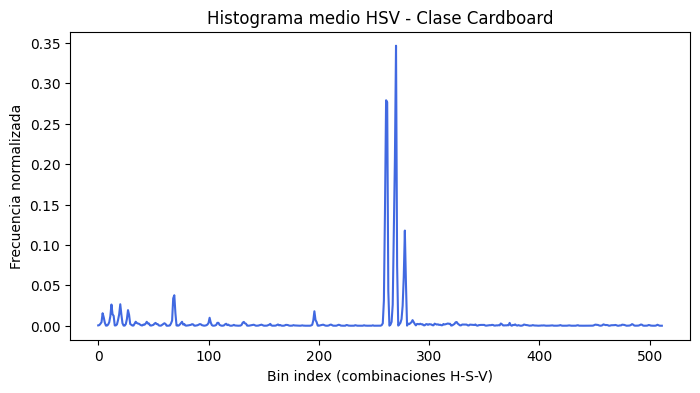

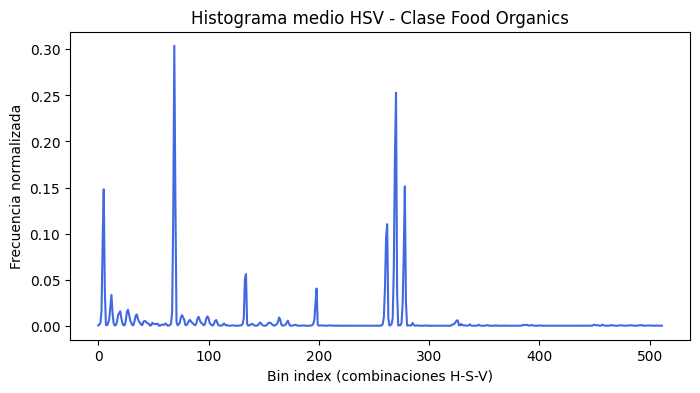

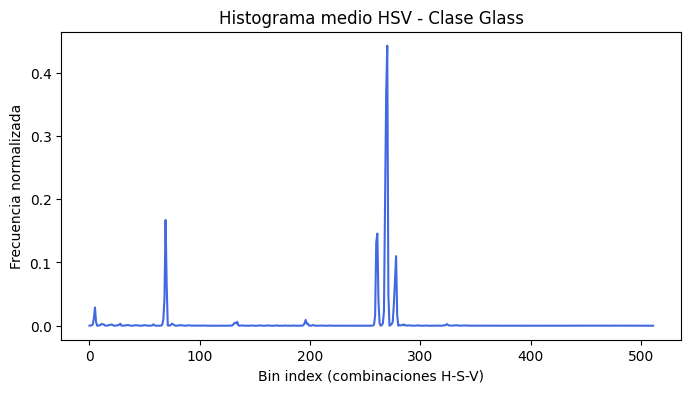

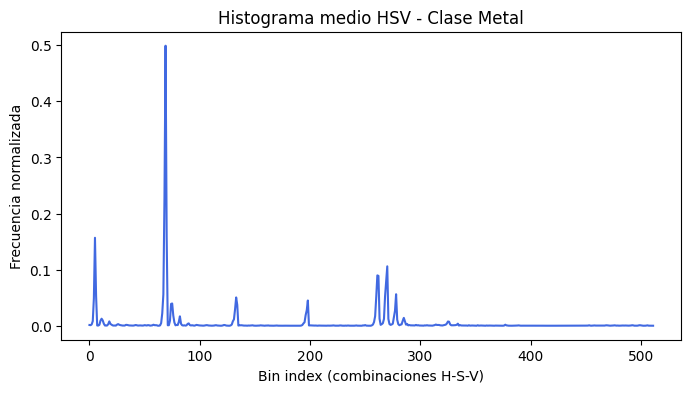

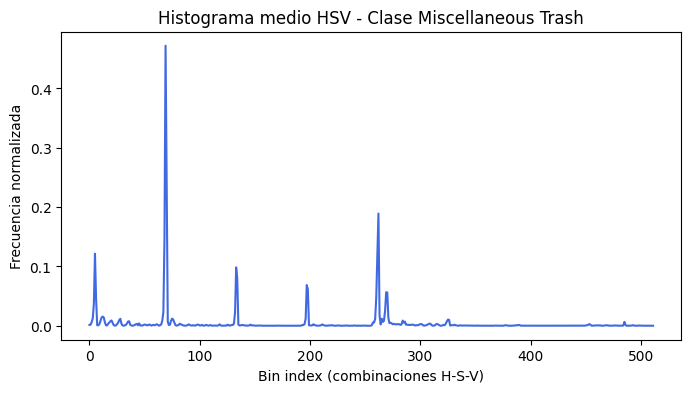

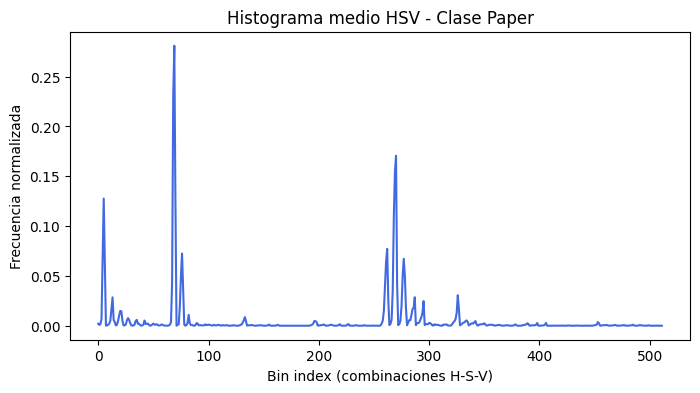

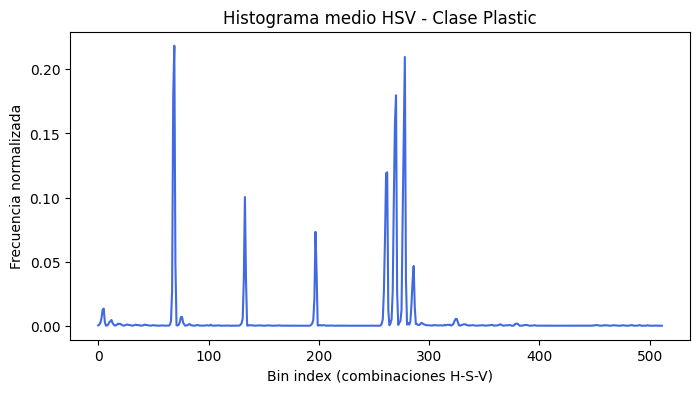

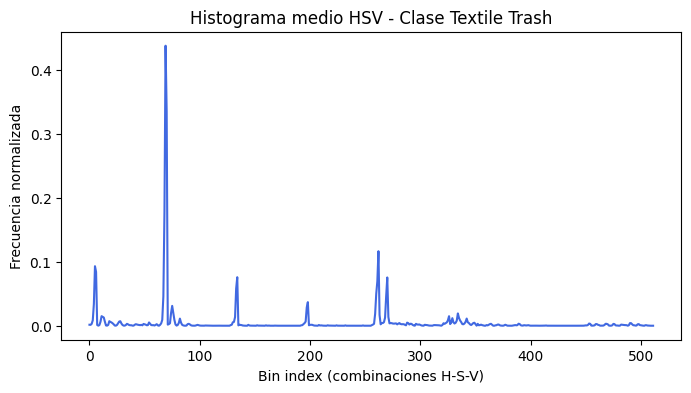

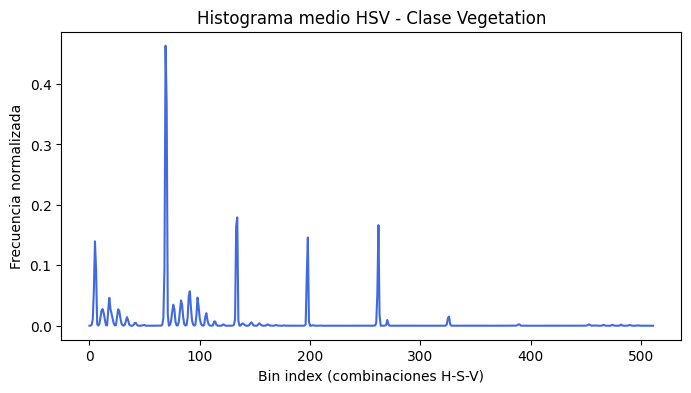

In [ ]:
# Calculamos el histograma medio de color por clase
bins = (8, 8, 8) #Número de bins por canal H,S,V
hist_per_class = {} #Histograma medio de color por clase
classes = sorted(list(set([label for _, label in train_data_color])))

for cls in classes:
    imgs = [img for img, label in train_data_color if label == cls][:100]
    histograms = [extract_color_histogram(img, bins=bins) for img in imgs]
    hist_per_class[cls] = np.mean(histograms, axis=0)

# Representamos los histogramas promediados por clase
for cls, hist in hist_per_class.items():
    plt.figure(figsize=(8,4))
    plt.plot(hist, color='royalblue')
    plt.title(f'Histograma medio HSV - Clase {cls}')
    plt.xlabel('Bin index (combinaciones H-S-V)')
    plt.ylabel('Frecuencia normalizada')
    plt.show()


Analizando las gráficas obtenidas, obtenemos las siguientes conclusiones:
 - Clase **Cardboard**: existe un pico principal con frecuencia 0.35 y bin 250-300 que representan la baja saturación y brillo medio.
 - Clase **Food Organics**: observamos más cantidad de picos comunes al haber gran variabilidad entre tonos cálidos y fríos propios de la mezcla de colores naturales.
 - Clase **Glass**: presencia de un pico principal indicando tonos fríos.
 - Clase **Metal**: pico principal y picos menos pronunciados que representa superficies grises-verdosas brillantes.
 - Clase **Miscellaneous Trash**: muy heterogénea con varias zonas de color sin predominio claro, es decir, mezcla de materiales y tonos.
 - Clase **Paper**: predominante en el rango 70 con tonos amarillentos y verdoso claro.
 - Clase **Plastic**: rango amplio predominando tonos cálidos y algo de fríos.
 - Clase **Textile Strash**: domonio de tonos verdosos y algunos fríos.
 - Clase **Vegetation**: predominación de verdes con componentes de sombras y brillos (causa de otros picos menos pronunciados).

Una vez hemos hecho el análisis por cada clase, vamos a observar el comportamiento HSV al unir la totalidad de clases.

Empezaremos graficándolo en 3D pudiendo ver los 3 ejes H, S, V y cómo se agrupan, por color, cada clase disponible:


In [ ]:
#Importamos librería para representar en 3D
import plotly.express as px

#--- 1.Configuración
classes = sorted(list(set([label for _, label in train_data_color])))

samples = []

for cls in classes:
    imgs = [img for img, label in train_data_color if label == cls][:100]
    for img in imgs:
        hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
        h = hsv[:, :, 0].flatten()
        s = hsv[:, :, 1].flatten()
        v = hsv[:, :, 2].flatten()
        df_temp = pd.DataFrame({'H': h, 'S': s, 'V': v})
        df_temp['Clase'] = cls
        samples.append(df_temp)

df_all = pd.concat(samples, ignore_index=True)

# Crear gráfica 3D interactiva
fig = px.scatter_3d(
    df_all.sample(50000),  # usamos una muestra para que no pese tanto
    x='H', y='S', z='V',
    color='Clase',
    opacity=0.6,
    title='Distribución de colores HSV por clase',
)

fig.update_traces(marker=dict(size=2))
fig.update_layout(
    width=1000,
    height=800,
    legend=dict(
        title='Clases',
        itemsizing='constant',  # mantiene el tamaño de los símbolos en la leyenda
        font=dict(size=12),     # tamaño del texto
        bgcolor='rgba(255,255,255,0.7)',  # fondo semitransparente
        bordercolor='black',
        borderwidth=1,
    ))
fig.show()


A nivel interpretativo, analizando el conjunto de las 9 clases distintas, apreciamos que para el parámetro H existen dos grupos diferenciados donde encontramos una concentración alredor de 100 y en valores menores a 50 siendo tonos cálidos y fríos, respectivamente. Para la saturación en S, se observa que la mayoría de puntos se concentran en valores menores a 100 teniendo más clases con colores apagados. Y por último, la componente V tiene todo su rango una distribución más o menos uniforme dado a la variabilidad de brillos altos, medios y medio-bajo.

Ahora lo haremos en 2D teniendo como ejes en X e Y a H y S:

In [ ]:
#Representación 2D
#plt.figure(figsize=(10,8))

fig_hs = px.scatter(
    df_all.sample(50000),  # muestra aleatoria para aligerar la visualización
    x='H', y='S',
    color='Clase',
    opacity=0.5,
    title='Proyección HSV: Hue vs Saturation',
    color_discrete_sequence=px.colors.qualitative.Bold
)
fig_hs.update_traces(marker=dict(size=4))
fig_hs.update_layout(
    xaxis_title='Hue (0–180)',
    yaxis_title='Saturation (0–255)',
    legend=dict(
        title='Clases',
        itemsizing='constant',   # mantiene tamaño fijo de marcador en leyenda
        font=dict(size=12),
        bgcolor='rgba(255,255,255,0.6)',
        bordercolor='black',
        borderwidth=1)
)
fig_hs.show()



#####**HOG - Histogram of Oriented Gradients**

Esta técnica captura bordes y contornos, es decir, cómo varian las intensidades de píxel. Aplicado a nuestro dataset, podemos conseguir la distinción de materiales con estructuras regulares o definidas como en Cardboard, Paper o Metal.

*Representación tridimensional HOG Feature Map (espacial)*

In [ ]:
#Definición de la función HOG en 3D
from skimage.feature import hog
import plotly.graph_objects as go
import numpy as np
import cv2

# Función para extraer características HOG 3D
def extract_hog_features_3D(image):
    features, hog_image = hog(image, orientations=9,
                              pixels_per_cell=(8, 8),
                              cells_per_block=(2, 2),
                              visualize=True,
                              block_norm='L2-Hys',
                              feature_vector=True)
    return features, hog_image  # usamos la imagen HOG para visualizar


In [ ]:
classes = sorted(list(set([label for _, label in train_data_texture])))

for cls in classes:
    img = [img for img, label in train_data_texture if label == cls][0]
    _, hog_img = extract_hog_features_3D(img)

    h, w = hog_img.shape
    X, Y = np.meshgrid(np.arange(w), np.arange(h))
    Z = hog_img

    fig = go.Figure(data=[go.Surface(
        x=X, y=Y, z=Z,
        colorscale='Viridis',
        showscale=True
    )])

    fig.update_layout(
        title=f"HOG Feature Map - Clase: {cls}",
        scene=dict(
            xaxis_title="Width (px)",
            yaxis_title="Height (px)",
            zaxis_title="Gradient magnitude"),
        width=700, height=600)
    fig.show()

*Interpretación del HOG Feature Map por clase en 3D:*

En esta gráfica, las zonas elevadas representan regiones con cambios bruscos de intensidad, es decir, bordes y texturas dominantes.

- Clase **Cardboard**: observamos una zona delimitada con valores en z significantes.

- Clase **Food Organics**: tenemos un mapa irregular como esperabamos al ser formas diferentes.

- Clase **Glass**: aquí distinguimos dos grupos dependiendo del eje 'Height' pero que son representativos.

- Clase **Metal**: se diferencia una zona bastante clara donde están todos los puntos concentrados.

- Clase **Miscellaneous Trash**: hay una zona delimitada pero los valores en z son irregulares no siendo significativos.

- Clase **Paper**: hay una zona delimitada pero los valores en z también son irregulares.

- Clase **Plastic**: aquí claramente se distingue una zona e incluso forma donde se concentran todos los puntos con valores en z significativos.

- Clase **Textile strash**: observamos algunos puntos donde Z aumenta pero no siendo significante.

- Clase **Vegetation**: un mapa bastante irregular.

En resumen, las clases que se diferencian en este estudio y de las cuales se puede obtener información interesante así como diferenciarlas del resto son Cardboard, Glass, Metal y Plastic.

#####**LBP - Local Binary Patterns**

Analiza la textura y rugosidad comparando cada píxel con sus vecinos inmediatos siendo insensible al color o la iluminación global. En nuestro caso, puede ser interesante en clases como Textile Trash al tener texturas irregulares o en Metal con textura lisa y uniforme.
Para ello, se calcula por clase el histograma medio de patrones uniformes.

*Representación histograma LBP medio por clase (surface/heatmap)*

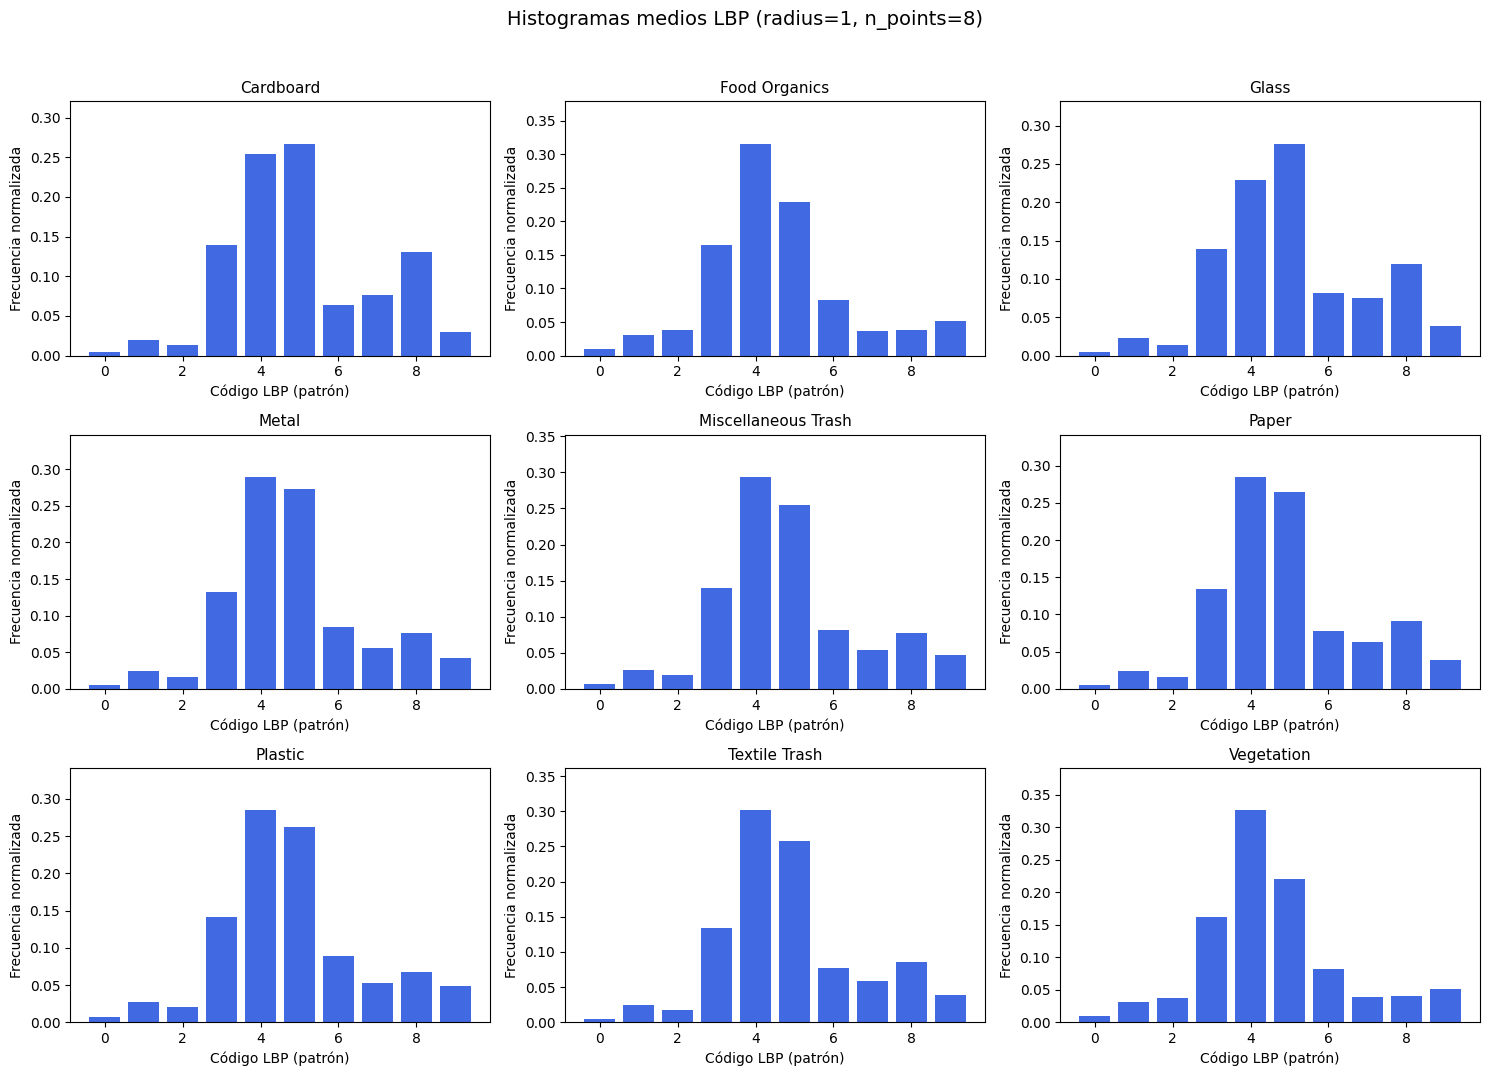

In [ ]:
from skimage.feature import local_binary_pattern
import matplotlib.pyplot as plt
import numpy as np

radius = 1
n_points = 8 * radius

def extract_lbp_histogram(image, n_points, radius):
    lbp = local_binary_pattern(image, n_points, radius, method='uniform')
    hist, _ = np.histogram(lbp.ravel(), bins=np.arange(0, n_points + 3), range=(0, n_points + 2))
    hist = hist.astype("float")
    hist /= (hist.sum() + 1e-7)
    return hist

classes = sorted(list(set([label for _, label in train_data_texture])))

# Configuración de subplots
n_classes = len(classes)
cols = 3  # número de columnas
rows = int(np.ceil(n_classes / cols))

plt.figure(figsize=(5 * cols, 3.5 * rows))
plt.suptitle(f'Histogramas medios LBP (radius={radius}, n_points={n_points})', fontsize=14, y=1.02)

for i, cls in enumerate(classes):
    imgs = [img for img, label in train_data_texture if label == cls][:200]
    histograms = [extract_lbp_histogram(img, n_points, radius) for img in imgs]
    mean_hist = np.mean(histograms, axis=0)

    ax = plt.subplot(rows, cols, i + 1)
    ax.bar(np.arange(len(mean_hist)), mean_hist, color='royalblue')
    ax.set_title(cls, fontsize=11)
    ax.set_xlabel('Código LBP (patrón)')
    ax.set_ylabel('Frecuencia normalizada')
    ax.set_ylim(0, max(mean_hist) * 1.2)

plt.tight_layout()
plt.show()



Como se puede observar, los histogramas LBP obtenidos son muy similares entre las clases con un pico dominante alrededor del código 4-5 y frecuencias normalizadas próximas a 0.2. Este resultado indica que las texturas locales de las distintas clases de residuos no muestran diferencias significativas a nivel de microtextura. Sin embargo, esto también es un resultado relevante ya que nos ayuda a saber qué característica no diferencia bien o de forma significativa las clases.

En conclusión, el LBP para esta configuración, no resulta un descriptor discriminativo útil para este conjunto de datos si no que parecen depender más de las propiedades cromáticas o geométricas que de la textura.

#####**GLCM - Gray Level Co-ocurrence Matrix**

Este descriptor mide cómo cambian los niveles de gris en la imagen según su vecindad, capturando texturas como homogeneidad, rugosidad o contraste.

A partir de esa matriz (GLCM), se calculan propiedades estadísticas:

- Contrast: mide las variaciones de intensidad entre píxeles vecinos.
  - Valores altos ⇒ texturas con mucho relieve o variabilidad (bordes, sombras, rugosidad).
  - Valores bajos ⇒ superficies lisas o homogéneas.

- Homogeneity → mide qué tan uniforme es la textura.
  - Alta homogeneidad ⇒ texturas suaves, sin mucho contraste.
  - Baja homogeneidad ⇒ texturas rugosas.

- Energy → mide la regularidad (orden) de la textura.
  - Alta energía ⇒ patrones repetitivos, regulares.
  - Baja energía ⇒ texturas más aleatorias.

- Correlation → mide la similitud lineal entre intensidades vecinas.
  - Alta correlación ⇒ patrones estructurados o graduales.
  - Baja ⇒ texturas desordenadas o con saltos abruptos


*Representación de características GLCM por clase*

In [ ]:
from skimage.feature import graycomatrix, graycoprops

def extract_glcm_features(image):
    #reduce los niveles a 32x32
    image = (image / 8).astype(np.uint8)

    # Calcular GLCM para varias orientaciones
    distances = [1, 2, 3]  # distancia entre píxeles
    angles = [0, np.pi/4, np.pi/2, 3*np.pi/4]
    glcm = graycomatrix(image,
                        distances=distances,
                        angles=angles,
                        levels=32,
                        symmetric=True,
                        normed=True)
    # Calcular propiedades estadísticas y promediarlas
    features = []
    for prop in ['contrast', 'homogeneity', 'energy', 'correlation']:
        features.append(graycoprops(glcm, prop).mean())

    return features


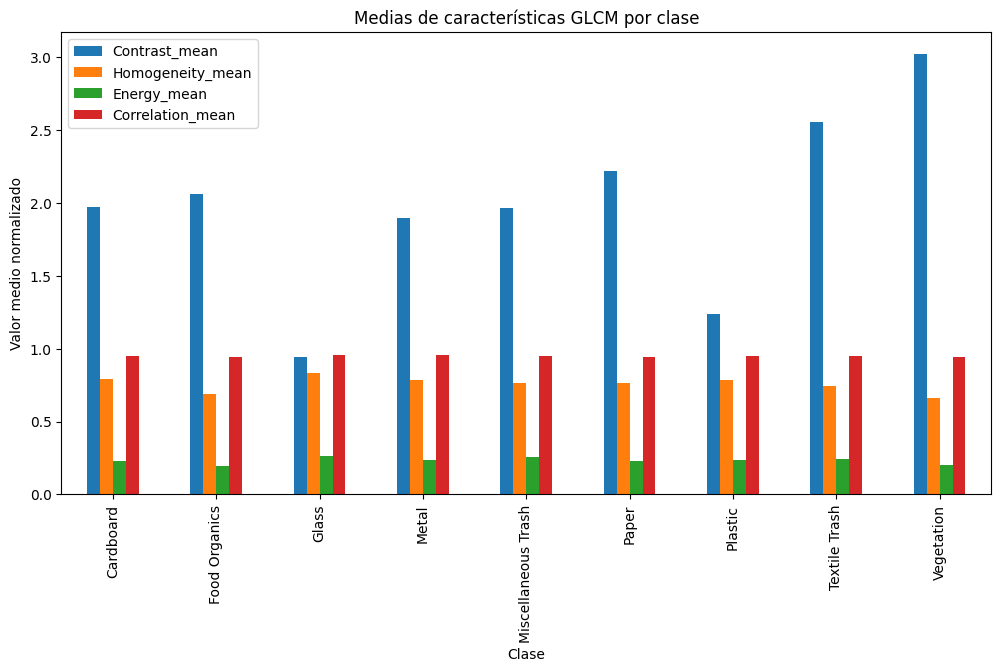

In [ ]:
classes = sorted(list(set([label for _, label in train_data_texture])))
data_glcm = []

for cls in classes:
    imgs = [img for img, label in train_data_texture if label == cls][:100]
    feats = [extract_glcm_features(img) for img in imgs]
    feats = np.array(feats)
    mean_feats = feats.mean(axis=0)
    std_feats = feats.std(axis=0)
    data_glcm.append((cls, *mean_feats, *std_feats))

columns = ['Clase', 'Contrast_mean', 'Homogeneity_mean', 'Energy_mean', 'Correlation_mean',
           'Contrast_std', 'Homogeneity_std', 'Energy_std', 'Correlation_std']

df_glcm = pd.DataFrame(data_glcm, columns=columns)

# --- Visualización ---
props = ['Contrast_mean', 'Homogeneity_mean', 'Energy_mean', 'Correlation_mean']
df_glcm.plot(x='Clase', y=props, kind='bar', figsize=(12,6))
plt.title("Medias de características GLCM por clase")
plt.ylabel("Valor medio normalizado")
plt.show()

El resultado que se observa es claro: todas las clases tienen la barra de 'Contrast_mean' con un valor medio normalizado más elevado al resto de características.

Por un lado, esto indica que la variación de intensidad (contraste) es la propiedad más distintiva entre las clases del dataset, es decir, los materiales se diferencian más por textura rugosa o lisa que por uniformidad o energía. Además, en relación con esta característica, las clases con valores más altos son aquellas con materiales naturales o irregulares (Vegetation, Food Organics, Paper) indicando una mayor variabilidad de intensidades.
Por el contrario, los materiales uniformes o reflectantes (Plastic, Glass) muestran contrastes bajos, lo que refleja superficies más lisas y homogéneas.
Este comportamiento es coherente con la naturaleza física de los objetos y confirma que el descriptor GLCM captura diferencias relevantes de textura entre clases.

###**4.3. Vectores de características - Train/Val/Test**

Para realizar el entrenamiento de modelos Machine Learning, es necesario obtener las características manualmente y cómo ya hemos analizado, podemos hacer uso de HSV, HOG, LBP o GLCM. Para ello, utilizando las funciones anteriormente creadas, calcularemos los vectores de características pertenecientes a los conjuntos de entrenamiento, evaluación y test.

Una vez realizado este punto, haremos uso de estos descriptores numéricos como entrada a los modelos Machine Learning entrenados. Pero, como hemos analizado, hemos obtenido cálculos para HSV, HOG, LBP y GLCM, por lo que hay que comprobar cuál es la combinación que obtiene los mejores resultados en las métricas de los modelos.

Con la finalidad de simplificar el código, creamos dos funciones: 'extract_all_features' que reúne las funciones que calculan las características HSV, HOG y GLCM, obteniendo de cada una un vector de características que luego se concatenan en un solo vector 1D para representar la imagen y 'feature_split_XY' que añade el vector de características a X (siendo una matriz de features) y la etiqueta a Y.

In [ ]:
#Función extracción de características HSV, HOG, GLCM
def extract_all_features(img_color, img_texture, use_hsv=True, use_hog=True, use_lbp=False, use_glcm=True):
  features=[]
  #HSV
  if use_hsv==True:
    hsv_f = extract_color_histogram(img_color, bins=(8,8,8))
    features.append(hsv_f.astype(np.float32)) #para que todos sean del mismo tipo

  #HOG
  if use_hog==True:
    hog_f, _ = extract_hog_features_3D(img_texture)
    features.append(hog_f.astype(np.float32))

  #LBP
  if use_lbp==True:
    radius = 1
    n_points = 8 * radius
    lbp_f = extract_lbp_histogram(img_texture, n_points, radius)
    features.append(lbp_f.astype(np.float32))

  #GLCM
  if use_glcm==True:
    glcm_f = extract_glcm_features(img_texture) #esta función devuelve una lista de 4 valores por las 4 características
    features.append(np.array(glcm_f, dtype=np.float32))

  return np.hstack(features)


In [ ]:
#Función construcción X e y
def feature_split_XY(data_color, data_texture, use_hsv=True, use_hog=True, use_lbp=False, use_glcm=True):
  X = []
  y = []

  #Recorremos las imagenes
  for (img_color, label1), (img_texture, label2) in zip(data_color, data_texture):
    #Asegurar que las etiquetas coinciden
    assert label1==label2, "Las etiquetas no coinciden"
    #Extracción de características
    feature = extract_all_features(img_color, img_texture,
                                   use_hsv=use_hsv,
                                   use_hog=use_hog,
                                   use_lbp=use_lbp,
                                   use_glcm=use_glcm)

    X.append(feature)
    y.append(label1)

  X = np.vstack(X) #queremos array 2D de forma (n imagenes, n features)
  y = np.array(y)

  return X, y

In [ ]:
#Aplicamos las funciones para train_data, val_data y test_data
X_train, y_train = feature_split_XY(train_data_color, train_data_texture, use_hsv=True, use_hog=False, use_lbp=False, use_glcm=True)
X_val, y_val = feature_split_XY(val_data_color, val_data_texture, use_hsv=True, use_hog=False, use_lbp=False, use_glcm=True)
X_test, y_test = feature_split_XY(test_data_color, test_data_texture, use_hsv=True, use_hog=False, use_lbp=False, use_glcm=True)

Tras haber realizado varias simulaciones, hemos obtenido que la combinación que da los mejores resultados es HSV y GLCM dejando atrás HOG y LBP.

###**4.4. Escalado**

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

##**5. ENTRENAMIENTO DE MODELOS ML**

###**5.1. SVM**

In [ ]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# Ejemplo SVM (con kernel RBF)
svc = SVC(kernel='rbf', C=1.0, gamma='scale', class_weight='balanced', probability=False, random_state=42)
svc.fit(X_train_scaled, y_train)
y_pred = svc.predict(X_test_scaled)
print("SVM Test acc:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


SVM Test acc: 0.6401673640167364
                     precision    recall  f1-score   support

          Cardboard       0.47      0.71      0.56        70
      Food Organics       0.72      0.69      0.70        62
              Glass       0.56      0.75      0.64        63
              Metal       0.74      0.55      0.63       119
Miscellaneous Trash       0.48      0.53      0.50        75
              Paper       0.79      0.65      0.72        75
            Plastic       0.66      0.60      0.63       139
      Textile Trash       0.74      0.48      0.58        48
         Vegetation       0.79      0.88      0.83        66

           accuracy                           0.64       717
          macro avg       0.66      0.65      0.64       717
       weighted avg       0.66      0.64      0.64       717



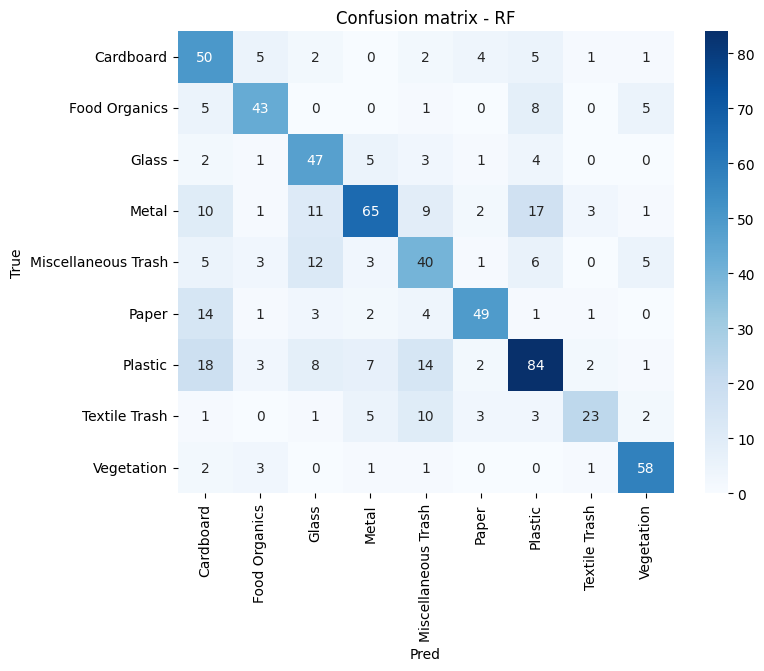

In [ ]:
cm = confusion_matrix(y_test, y_pred, labels=svc.classes_)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=svc.classes_, yticklabels=svc.classes_, cmap='Blues')
plt.ylabel('True'); plt.xlabel('Pred'); plt.title('Confusion matrix - RF')
plt.show()

###**5.2. Random Forest**

In [ ]:
rf = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)
print("RF Test acc:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


RF Test acc: 0.797768479776848
                     precision    recall  f1-score   support

          Cardboard       0.71      0.79      0.75        70
      Food Organics       0.89      0.79      0.84        62
              Glass       0.90      0.68      0.77        63
              Metal       0.75      0.79      0.77       119
Miscellaneous Trash       0.82      0.71      0.76        75
              Paper       0.86      0.83      0.84        75
            Plastic       0.74      0.85      0.79       139
      Textile Trash       0.91      0.67      0.77        48
         Vegetation       0.81      1.00      0.90        66

           accuracy                           0.80       717
          macro avg       0.82      0.79      0.80       717
       weighted avg       0.81      0.80      0.80       717



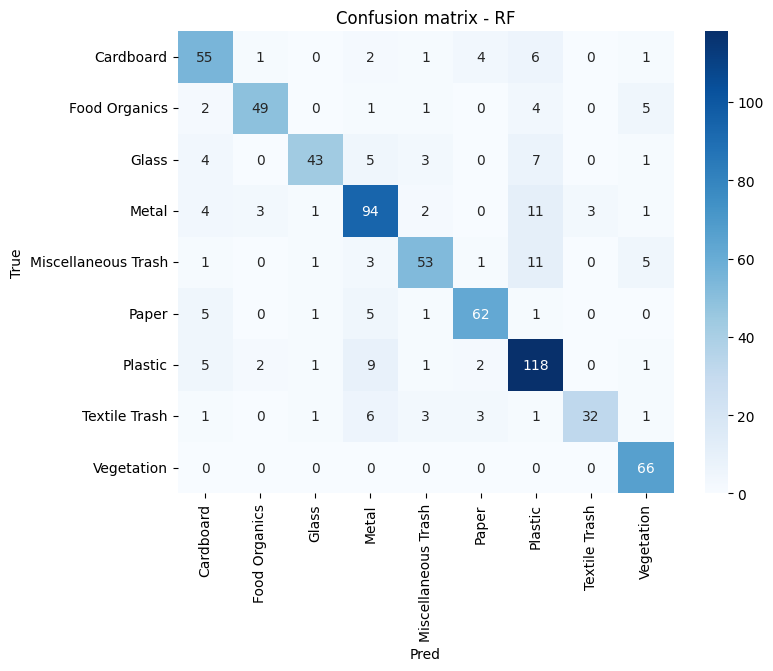

In [ ]:
cm = confusion_matrix(y_test, y_pred_rf, labels=rf.classes_)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=rf.classes_, yticklabels=rf.classes_, cmap='Blues')
plt.ylabel('True'); plt.xlabel('Pred'); plt.title('Confusion matrix - RF')
plt.savefig("cmRF.png")
plt.show()


###**5.3. Gradient Boosting**

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

gb = GradientBoostingClassifier(n_estimators=200, random_state=42)
gb.fit(X_train_scaled, y_train)
y_pred_gb = gb.predict(X_test_scaled)
print("GB Test acc:", accuracy_score(y_test, y_pred_gb))
print(classification_report(y_test, y_pred_gb))


GB Test acc: 0.7591973244147158
                     precision    recall  f1-score   support

          Cardboard       0.73      0.62      0.67        58
      Food Organics       0.85      0.87      0.86        52
              Glass       0.78      0.68      0.73        53
              Metal       0.76      0.79      0.78        99
Miscellaneous Trash       0.65      0.66      0.66        62
              Paper       0.88      0.71      0.79        63
            Plastic       0.66      0.87      0.75       116
      Textile Trash       0.86      0.62      0.72        40
         Vegetation       0.90      0.85      0.88        55

           accuracy                           0.76       598
          macro avg       0.79      0.74      0.76       598
       weighted avg       0.77      0.76      0.76       598



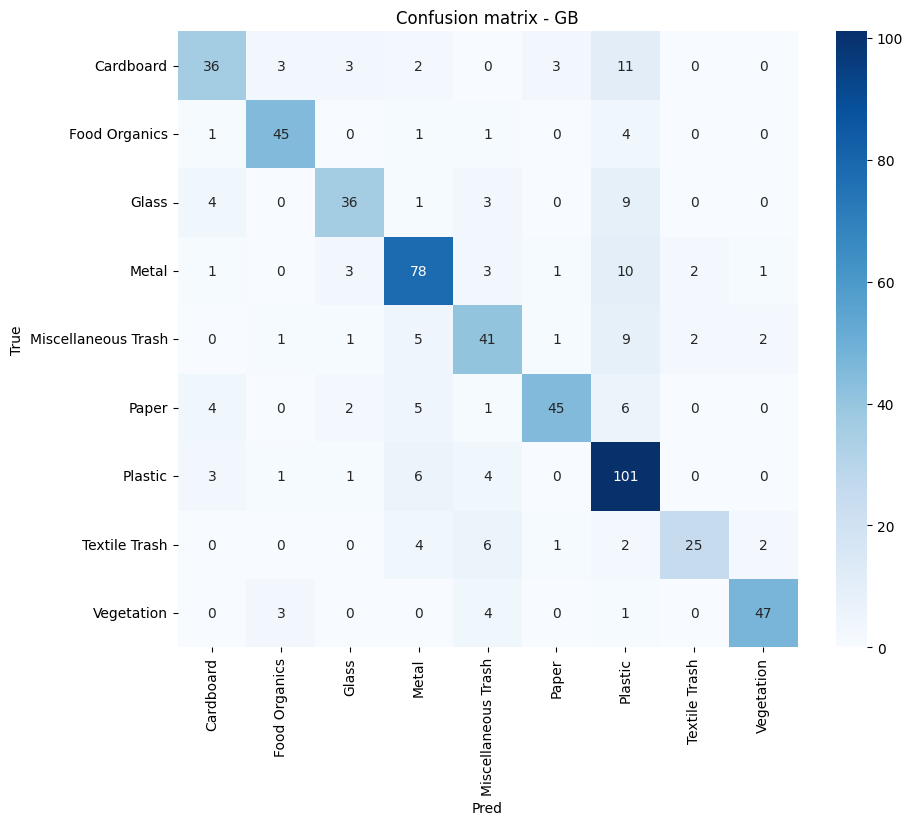

In [ ]:
cm = confusion_matrix(y_test, y_pred_gb, labels=gb.classes_)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=gb.classes_, yticklabels=gb.classes_, cmap='Blues')
plt.ylabel('True'); plt.xlabel('Pred'); plt.title('Confusion matrix - GB')
plt.show()

###**5.4. XGBoost**

Para XGBoost es necesario convertir y_train, y_val e y_test en valores numéricos ya que no acepta strings.

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Ajustas solo con el training
y_train_enc = le.fit_transform(y_train)

# Transformas usando el mismo encoder
y_val_enc = le.transform(y_val)
y_test_enc = le.transform(y_test)


In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=400,
    random_state=42
)

xgb.fit(X_train_scaled, y_train_enc)

# Predicción
y_pred_xgb = xgb.predict(X_test_scaled)
y_pred_labels = le.inverse_transform(y_pred_xgb)
y_test_labels = le.inverse_transform(y_test_enc)

print("XGBoost Test acc:", accuracy_score(y_test_labels, y_pred_labels))
print(classification_report(y_test_labels, y_pred_labels))

XGBoost Test acc: 0.8177257525083612
                     precision    recall  f1-score   support

          Cardboard       0.82      0.81      0.82        58
      Food Organics       0.87      0.92      0.90        52
              Glass       0.85      0.74      0.79        53
              Metal       0.83      0.84      0.83        99
Miscellaneous Trash       0.75      0.63      0.68        62
              Paper       0.89      0.79      0.84        63
            Plastic       0.74      0.89      0.81       116
      Textile Trash       0.81      0.75      0.78        40
         Vegetation       0.89      0.91      0.90        55

           accuracy                           0.82       598
          macro avg       0.83      0.81      0.82       598
       weighted avg       0.82      0.82      0.82       598



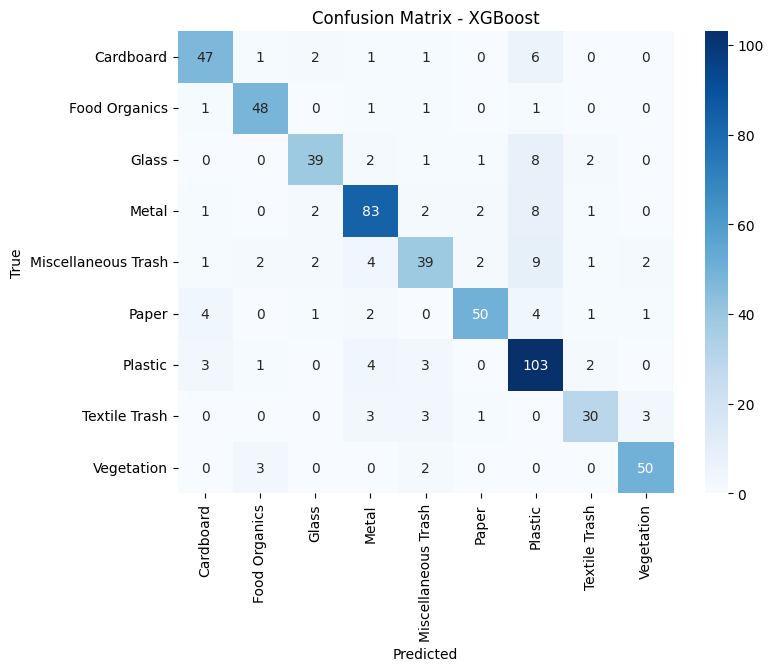

In [ ]:
# Matriz de confusión
cm_xgb = confusion_matrix(y_test_labels, y_pred_labels, labels=le.classes_)
plt.figure(figsize=(8,6))
sns.heatmap(cm_xgb, annot=True, fmt='d',
            xticklabels=le.classes_, yticklabels=le.classes_, cmap='Blues')
plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.show()

###**5.5. CatBoost**

In [ ]:
pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 5.7 MB/s eta 0:00:00


In [ ]:
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# CatBoost no requiere escalado
cat = CatBoostClassifier(
    iterations=1000,
    loss_function='MultiClass',
    verbose=100,
    random_seed=42
)

# Entrenamiento
cat.fit(X_train, y_train_enc, eval_set=(X_val, y_val_enc))

Learning rate set to 0.110754
0:	learn: 2.0996225	test: 2.1079023	best: 2.1079023 (0)	total: 1.74s	remaining: 28m 54s
100:	learn: 0.7663500	test: 1.0198499	best: 1.0198499 (100)	total: 1m 18s	remaining: 11m 41s
200:	learn: 0.5400952	test: 0.8598658	best: 0.8598658 (200)	total: 2m 36s	remaining: 10m 22s
300:	learn: 0.4345624	test: 0.7921167	best: 0.7921167 (300)	total: 3m 50s	remaining: 8m 55s
400:	learn: 0.3566570	test: 0.7449963	best: 0.7449963 (400)	total: 5m 6s	remaining: 7m 37s
500:	learn: 0.3005299	test: 0.7082298	best: 0.7082298 (500)	total: 6m 21s	remaining: 6m 19s
600:	learn: 0.2578391	test: 0.6799310	best: 0.6797519 (597)	total: 7m 35s	remaining: 5m 2s
700:	learn: 0.2216993	test: 0.6551483	best: 0.6551483 (700)	total: 8m 52s	remaining: 3m 47s
800:	learn: 0.1949274	test: 0.6410539	best: 0.6410539 (800)	total: 10m 9s	remaining: 2m 31s
900:	learn: 0.1715150	test: 0.6272805	best: 0.6271311 (890)	total: 11m 25s	remaining: 1m 15s
999:	learn: 0.1494753	test: 0.6130236	best: 0.6130190

CatBoost Test acc: 0.8076923076923077
                     precision    recall  f1-score   support

          Cardboard       0.84      0.74      0.79        58
      Food Organics       0.91      0.92      0.91        52
              Glass       0.80      0.74      0.76        53
              Metal       0.79      0.85      0.82        99
Miscellaneous Trash       0.71      0.58      0.64        62
              Paper       0.85      0.79      0.82        63
            Plastic       0.73      0.88      0.80       116
      Textile Trash       0.91      0.72      0.81        40
         Vegetation       0.91      0.95      0.93        55

           accuracy                           0.81       598
          macro avg       0.83      0.80      0.81       598
       weighted avg       0.81      0.81      0.81       598



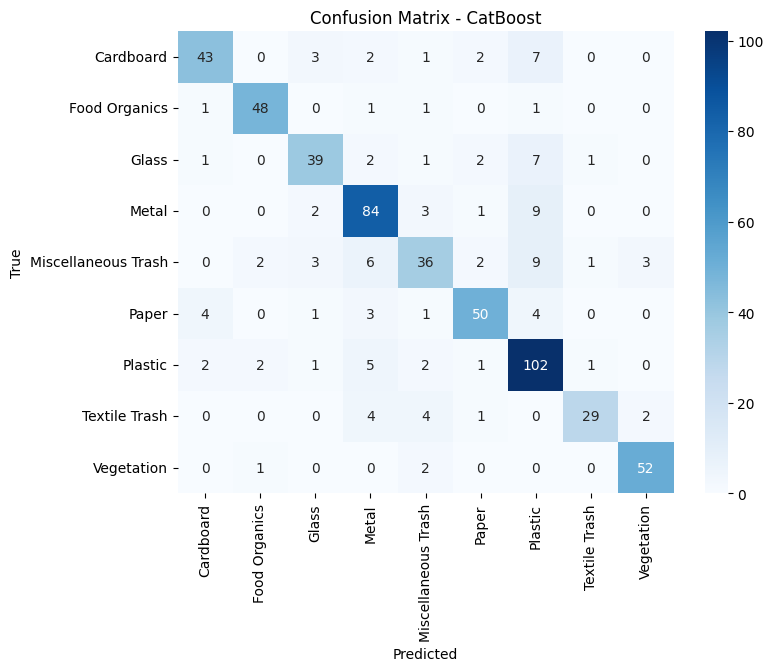

In [ ]:
# Predicción
y_pred_cat = cat.predict(X_test)
y_pred_cat = y_pred_cat.flatten()
y_pred_cat_labels = le.inverse_transform(y_pred_cat)

print("CatBoost Test acc:", accuracy_score(y_test_labels, y_pred_cat_labels))
print(classification_report(y_test_labels, y_pred_cat_labels))

# Matriz de confusión
cm_cat = confusion_matrix(y_test_labels, y_pred_cat_labels, labels=le.classes_)
plt.figure(figsize=(8,6))
sns.heatmap(cm_cat, annot=True, fmt='d',
            xticklabels=le.classes_, yticklabels=le.classes_, cmap='Blues')
plt.title("Confusion Matrix - CatBoost")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.show()

Tras haber entrenado estos modelos obtenemos que las mejores métricas obtenidas pertenecen, por orden de mejor a peor:
 - XGBoost
 - CatBoost
 - Random Forest

Por tanto, procedemos a optimizar con el ajuste de los hiperparámetros.

##**6. Optimización. Ajuste de hiperparámetros**

### **6.1. Ranfom Forest**

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid_rf = {
    "n_estimators": [900, 1000, 1100],
    "max_depth": [None, 5],
    "min_samples_split": [2],
    "min_samples_leaf": [1],
    "max_features": ["sqrt"],
    "class_weight": ["balanced"]
}

grid_rf = GridSearchCV(RandomForestClassifier(random_state=42),
                       param_grid_rf,
                       cv=5,
                       scoring="f1_weighted",
                       n_jobs=-1,
                       verbose=2)
grid_rf.fit(X_train_scaled, y_train)

print("Best params RF:", grid_rf.best_params_)
print("Best score RF:", grid_rf.best_score_)


Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best params RF: {'class_weight': 'balanced', 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 1000}
Best score RF: 0.775189613630534


In [ ]:
#Tras obtener los parámetros, probamos a volver a entrenar el modelo siguiendo esto
from sklearn.metrics import accuracy_score, recall_score, roc_auc_score
rf_best = RandomForestClassifier(class_weight='balanced', max_depth=None, max_features='sqrt', min_samples_leaf=1, min_samples_split=2, n_estimators=1000, random_state=42)
rf_best.fit(X_train_scaled, y_train)
y_pred_rf_best = rf_best.predict(X_test_scaled)

In [ ]:
#valores obtenidos anteriormente:
print("RF Test acc:", accuracy_score(y_test, y_pred_rf_best))
print(classification_report(y_test, y_pred_rf_best))

RF Test acc: 0.782608695652174
                     precision    recall  f1-score   support

          Cardboard       0.72      0.72      0.72        58
      Food Organics       0.96      0.85      0.90        52
              Glass       0.88      0.66      0.75        53
              Metal       0.76      0.79      0.77        99
Miscellaneous Trash       0.74      0.55      0.63        62
              Paper       0.90      0.83      0.86        63
            Plastic       0.65      0.87      0.74       116
      Textile Trash       0.97      0.72      0.83        40
         Vegetation       0.87      0.96      0.91        55

           accuracy                           0.78       598
          macro avg       0.83      0.77      0.79       598
       weighted avg       0.80      0.78      0.78       598



###**6.2. XGBoost**

In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

param_grid_xgb = {
    "n_estimators": [400, 500],
    "learning_rate": [0.03, 0.05],
    "max_depth": [6, 8]
}

grid_xgb = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='mlogloss'),
    param_grid_xgb,
    cv=3,
    scoring="f1_weighted",
    n_jobs=-1,
    verbose=2)

grid_xgb.fit(X_train_scaled, y_train_enc)

print("Best params GB:", grid_xgb.best_params_)
print("Best score GB:", grid_xgb.best_score_)


Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best params GB: {'learning_rate': 0.05, 'max_depth': 8, 'n_estimators': 500}
Best score GB: 0.7709252427883072


In [ ]:
#Tras obtener los parámetros, probamos a volver a entrenar el modelo siguiendo esto
from sklearn.metrics import accuracy_score, recall_score, roc_auc_score
from xgboost import XGBClassifier

xgb_best = XGBClassifier(max_depth=10, n_estimators=900, learning_rate=0.06, random_state=42)
xgb_best.fit(X_train_scaled, y_train_enc)
y_pred_xgb_best = xgb_best.predict(X_test_scaled)

In [ ]:
# Predicción
y_pred_labels = le.inverse_transform(y_pred_xgb_best)
y_test_labels = le.inverse_transform(y_test_enc)

print("XGBoost Test acc:", accuracy_score(y_test_labels, y_pred_labels))
print(classification_report(y_test_labels, y_pred_labels))

XGBoost Test acc: 0.8131101813110181
                     precision    recall  f1-score   support

          Cardboard       0.79      0.83      0.81        70
      Food Organics       0.89      0.89      0.89        62
              Glass       0.87      0.76      0.81        63
              Metal       0.82      0.82      0.82       119
Miscellaneous Trash       0.74      0.72      0.73        75
              Paper       0.85      0.84      0.85        75
            Plastic       0.76      0.84      0.80       139
      Textile Trash       0.72      0.60      0.66        48
         Vegetation       0.91      0.94      0.93        66

           accuracy                           0.81       717
          macro avg       0.82      0.80      0.81       717
       weighted avg       0.81      0.81      0.81       717



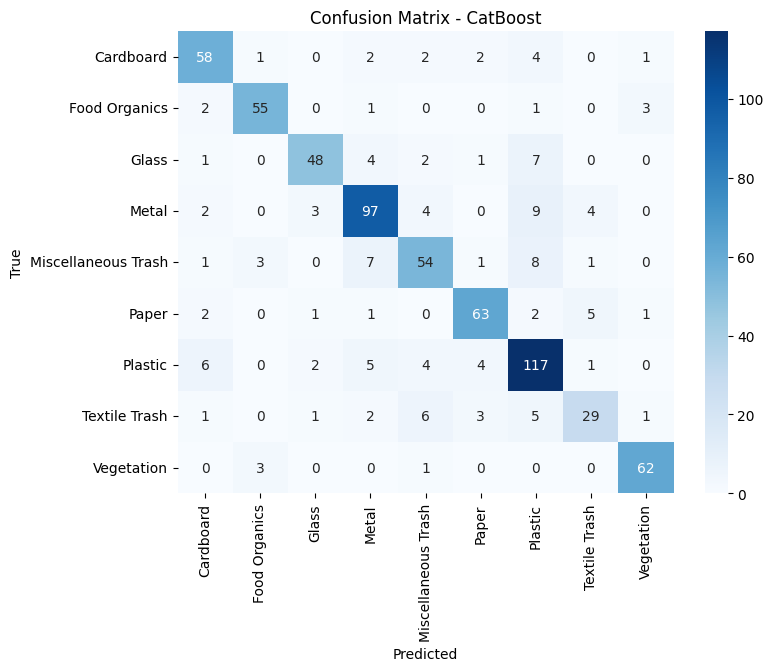

In [ ]:
# Matriz de confusión
cm_xgboost_best = confusion_matrix(y_test_labels, y_pred_labels, labels=le.classes_)
plt.figure(figsize=(8,6))
sns.heatmap(cm_xgboost_best, annot=True, fmt='d',
            xticklabels=le.classes_, yticklabels=le.classes_, cmap='Blues')
plt.title("Confusion Matrix - CatBoost")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.show()

###**6.3. CatBoost**

In [ ]:
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# CatBoost no requiere escalado
cat_best = CatBoostClassifier(
    iterations=1500,
    learning_rate=0.05,
    loss_function='MultiClass',
    verbose=100,
    random_seed=42
)

# Entrenamiento
cat_best.fit(X_train, y_train_enc, eval_set=(X_val, y_val_enc))

0:	learn: 2.1519384	test: 2.1557086	best: 2.1557086 (0)	total: 3.25s	remaining: 1h 21m 11s
100:	learn: 1.0752540	test: 1.2446879	best: 1.2446879 (100)	total: 2m 18s	remaining: 31m 51s
200:	learn: 0.8124345	test: 1.0481624	best: 1.0481624 (200)	total: 3m 34s	remaining: 23m 8s
300:	learn: 0.6563401	test: 0.9322662	best: 0.9322662 (300)	total: 4m 51s	remaining: 19m 22s
400:	learn: 0.5660509	test: 0.8672168	best: 0.8672168 (400)	total: 6m 7s	remaining: 16m 48s
500:	learn: 0.5022955	test: 0.8230223	best: 0.8230223 (500)	total: 7m 24s	remaining: 14m 47s
600:	learn: 0.4551788	test: 0.7934132	best: 0.7934132 (600)	total: 8m 40s	remaining: 12m 59s
700:	learn: 0.4139324	test: 0.7648906	best: 0.7648906 (700)	total: 9m 55s	remaining: 11m 18s
800:	learn: 0.3817032	test: 0.7445529	best: 0.7445529 (800)	total: 11m 11s	remaining: 9m 45s
900:	learn: 0.3523497	test: 0.7274268	best: 0.7274268 (900)	total: 12m 26s	remaining: 8m 16s
1000:	learn: 0.3260150	test: 0.7127597	best: 0.7127001 (998)	total: 13m 41

CatBoost Test acc: 0.8193979933110368
                     precision    recall  f1-score   support

          Cardboard       0.82      0.72      0.77        58
      Food Organics       0.92      0.88      0.90        52
              Glass       0.87      0.75      0.81        53
              Metal       0.80      0.86      0.83        99
Miscellaneous Trash       0.77      0.65      0.70        62
              Paper       0.89      0.79      0.84        63
            Plastic       0.72      0.90      0.80       116
      Textile Trash       0.91      0.72      0.81        40
         Vegetation       0.90      0.98      0.94        55

           accuracy                           0.82       598
          macro avg       0.84      0.81      0.82       598
       weighted avg       0.83      0.82      0.82       598



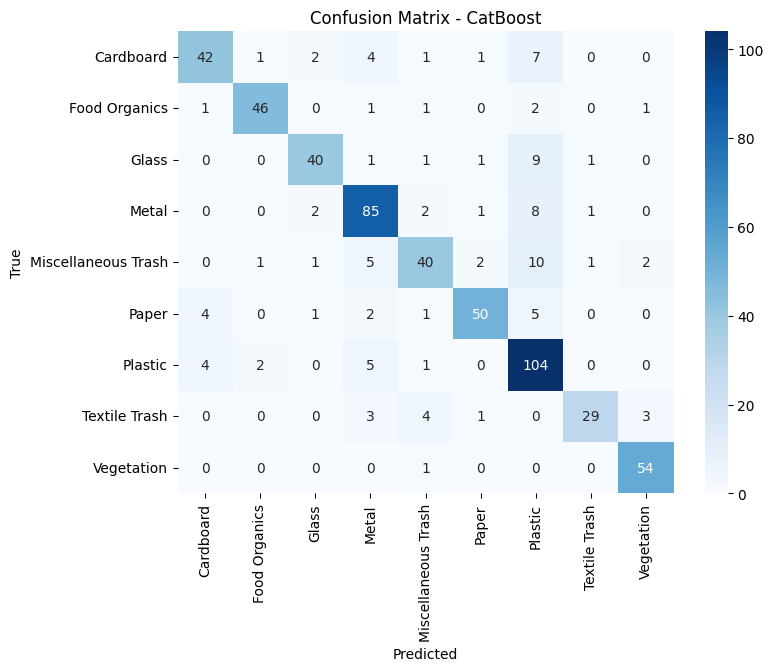

In [ ]:
# Predicción
y_pred_cat_best = cat_best.predict(X_test)
y_pred_cat_best = y_pred_cat_best.flatten()
y_pred_cat_labels = le.inverse_transform(y_pred_cat_best)

print("CatBoost Test acc:", accuracy_score(y_test_labels, y_pred_cat_labels))
print(classification_report(y_test_labels, y_pred_cat_labels))

# Matriz de confusión
cm_cat_best = confusion_matrix(y_test_labels, y_pred_cat_labels, labels=le.classes_)
plt.figure(figsize=(8,6))
sns.heatmap(cm_cat_best, annot=True, fmt='d',
            xticklabels=le.classes_, yticklabels=le.classes_, cmap='Blues')
plt.title("Confusion Matrix - CatBoost")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.show()

##*ENFOQUE B - DEEP LEARNING CON CNN PREENTRENADA*

##**7. Data Augmentation**

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# reescalamos las imágenes de train con un generador
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True)
# reescalamos las imágenes de test con un generador
validation_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True)

# usamos generador para leer las imágenes desde los directorios
# genera lotes de 20 imágenes de 128x128 RGB con 9 clases (categorical)
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size = (224, 224),
    batch_size = 32,
    class_mode='categorical',
    shuffle=True
)

# hacemos lo mismo para la validación usando test_datagen
validation_generator = validation_datagen.flow_from_directory(
    validation_dir,
    target_size = (224, 224),
    batch_size = 32,
    class_mode='categorical'
)

Found 3561 images belonging to 9 classes.
Found 593 images belonging to 9 classes.


In [ ]:
test_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size = (224, 224),
    batch_size = 32,
    class_mode='categorical',
    shuffle=False
)

Found 598 images belonging to 9 classes.


##**8. Red CNN preentrenada**

###**8.1. Con MobileNetV2**

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models, optimizers
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense
from tensorflow.keras.preprocessing.image import ImageDataGenerator

num_classes = 9
#Cargamos la base convolucional preentrenada
conv_base = MobileNetV2(
    weights='imagenet',
    include_top=False,          # quitamos las capas densas originales
    input_shape=(224, 224, 3)
)

#Congelamos la base convulucional
conv_base.trainable=False

#Definición del modelo
model_pre = models.Sequential([
    conv_base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])

#Compilar
model_pre.compile(
    optimizer=optimizers.RMSprop(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy', 'precision', 'recall']
)


In [ ]:
#Entrenamiento
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True)

lr_reduce = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    verbose=1)


history_pre = model_pre.fit(
    train_generator,
    epochs=30,
    validation_data=validation_generator,
    callbacks=[early_stop, lr_reduce]

)

Epoch 1/30
112/112 ━━━━━━━━━━━━━━━━━━━━ 89s 678ms/step - accuracy: 0.2275 - loss: 2.1401 - precision: 0.3163 - recall: 0.0288 - val_accuracy: 0.5514 - val_loss: 1.3601 - val_precision: 0.8279 - val_recall: 0.1703 - learning_rate: 1.0000e-04
Epoch 2/30
112/112 ━━━━━━━━━━━━━━━━━━━━ 61s 547ms/step - accuracy: 0.4918 - loss: 1.4549 - precision: 0.6752 - recall: 0.2321 - val_accuracy: 0.6020 - val_loss: 1.1192 - val_precision: 0.8125 - val_recall: 0.3727 - learning_rate: 1.0000e-04
Epoch 3/30
112/112 ━━━━━━━━━━━━━━━━━━━━ 61s 541ms/step - accuracy: 0.5706 - loss: 1.2132 - precision: 0.7227 - recall: 0.3802 - val_accuracy: 0.6560 - val_loss: 0.9622 - val_precision: 0.8249 - val_recall: 0.4688 - learning_rate: 1.0000e-04
Epoch 4/30
112/112 ━━━━━━━━━━━━━━━━━━━━ 61s 543ms/step - accuracy: 0.6041 - loss: 1.1155 - precision: 0.7374 - recall: 0.4533 - val_accuracy: 0.6577 - val_loss: 0.9551 - val_precision: 0.7968 - val_recall: 0.5025 - learning_rate: 1.0000e-04
Epoch 5/30
112/112 ━━━━━━━━━━━━━━━━━

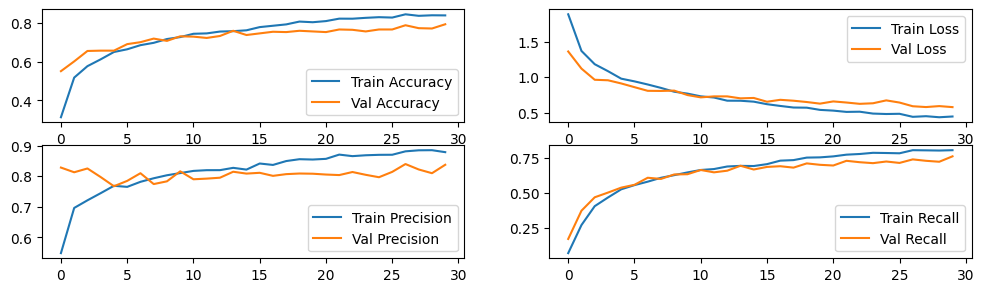

In [ ]:
import matplotlib.pyplot as plt

acc = history_pre.history['accuracy']
val_acc = history_pre.history['val_accuracy']
loss = history_pre.history['loss']
val_loss = history_pre.history['val_loss']
precision = history_pre.history['precision']
val_precision = history_pre.history['val_precision']
recall = history_pre.history['recall']
val_recall = history_pre.history['val_recall']

epochs_range = range(len(acc))

plt.figure(figsize=(12,5))

plt.subplot(3,2,1)
plt.plot(epochs_range, acc, label="Train Accuracy")
plt.plot(epochs_range, val_acc, label="Val Accuracy")
plt.legend()

plt.subplot(3,2,2)
plt.plot(epochs_range, loss, label="Train Loss")
plt.plot(epochs_range, val_loss, label="Val Loss")
plt.legend()

plt.subplot(3,2,3)
plt.plot(epochs_range, precision, label="Train Precision")
plt.plot(epochs_range, val_precision, label="Val Precision")
plt.legend()

plt.subplot(3,2,4)
plt.plot(epochs_range, recall, label="Train Recall")
plt.plot(epochs_range, val_recall, label="Val Recall")
plt.legend()

plt.show()


19/19 ━━━━━━━━━━━━━━━━━━━━ 18s 696ms/step


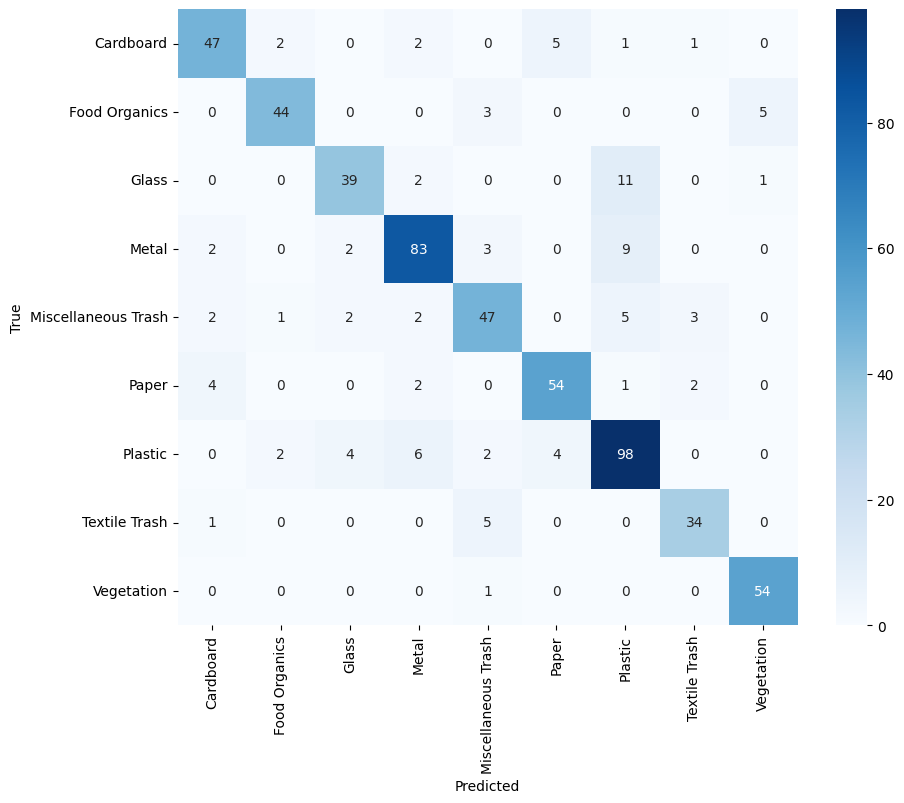

                     precision    recall  f1-score   support

          Cardboard       0.84      0.81      0.82        58
      Food Organics       0.90      0.85      0.87        52
              Glass       0.83      0.74      0.78        53
              Metal       0.86      0.84      0.85        99
Miscellaneous Trash       0.77      0.76      0.76        62
              Paper       0.86      0.86      0.86        63
            Plastic       0.78      0.84      0.81       116
      Textile Trash       0.85      0.85      0.85        40
         Vegetation       0.90      0.98      0.94        55

           accuracy                           0.84       598
          macro avg       0.84      0.84      0.84       598
       weighted avg       0.84      0.84      0.84       598



In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# obtener predicciones
y_pred = model_pre.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)

y_true = test_generator.classes
class_names = list(test_generator.class_indices.keys())

# matriz
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.ylabel("True")
plt.xlabel("Predicted")
plt.show()

print(classification_report(y_true, y_pred_classes, target_names=class_names))

#### **8.1.1. Fine tuning**

In [ ]:
# 1️⃣ Descongelamos las últimas capas de MobileNetV2
conv_base.trainable = True

# Solo entrenamos las últimas 30 capas (ajusta según memoria y resultados)
for layer in conv_base.layers[:-30]:
    layer.trainable = False

# 2️⃣ Compilamos de nuevo con un learning rate bajo
model_pre.compile(
    optimizer=optimizers.RMSprop(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy', 'precision', 'recall']
)

# 3️⃣ Callbacks: EarlyStopping y ReduceLROnPlateau
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

lr_reduce = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    verbose=1
)

# 4️⃣ Entrenamiento fine-tuning
history_ft = model_pre.fit(
    train_generator,
    epochs=20,  # menos que entrenamiento inicial
    validation_data=validation_generator,
    callbacks=[early_stop, lr_reduce]
)

Epoch 1/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 98s 708ms/step - accuracy: 0.8599 - loss: 0.3949 - precision: 0.8938 - recall: 0.8353 - val_accuracy: 0.8078 - val_loss: 0.5766 - val_precision: 0.8432 - val_recall: 0.7892 - learning_rate: 1.0000e-05
Epoch 2/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 61s 547ms/step - accuracy: 0.8546 - loss: 0.4224 - precision: 0.8857 - recall: 0.8136 - val_accuracy: 0.8196 - val_loss: 0.5354 - val_precision: 0.8519 - val_recall: 0.7858 - learning_rate: 1.0000e-05
Epoch 3/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 62s 552ms/step - accuracy: 0.8686 - loss: 0.3615 - precision: 0.9005 - recall: 0.8359 - val_accuracy: 0.8263 - val_loss: 0.5588 - val_precision: 0.8429 - val_recall: 0.7960 - learning_rate: 1.0000e-05
Epoch 4/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 62s 551ms/step - accuracy: 0.8655 - loss: 0.3844 - precision: 0.8911 - recall: 0.8378 - val_accuracy: 0.7943 - val_loss: 0.5712 - val_precision: 0.8225 - val_recall: 0.7656 - learning_rate: 1.0000e-05
Epoch 5/20
112/112 ━━━━━━━━━━━━━━━━━

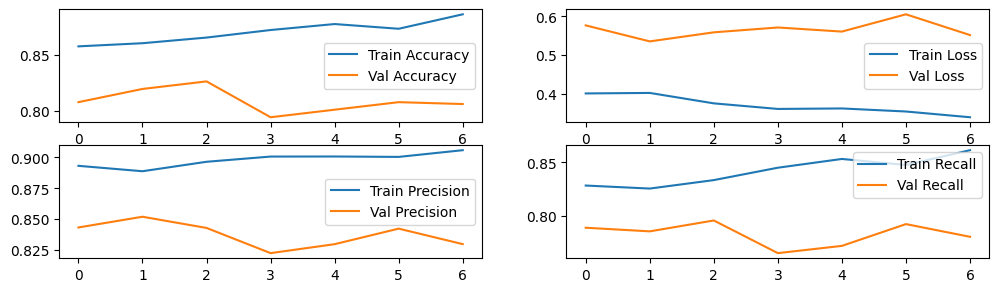

In [ ]:
import matplotlib.pyplot as plt

acc = history_ft.history['accuracy']
val_acc = history_ft.history['val_accuracy']
loss = history_ft.history['loss']
val_loss = history_ft.history['val_loss']
precision = history_ft.history['precision']
val_precision = history_ft.history['val_precision']
recall = history_ft.history['recall']
val_recall = history_ft.history['val_recall']

epochs_range = range(len(acc))

plt.figure(figsize=(12,5))

plt.subplot(3,2,1)
plt.plot(epochs_range, acc, label="Train Accuracy")
plt.plot(epochs_range, val_acc, label="Val Accuracy")
plt.legend()

plt.subplot(3,2,2)
plt.plot(epochs_range, loss, label="Train Loss")
plt.plot(epochs_range, val_loss, label="Val Loss")
plt.legend()

plt.subplot(3,2,3)
plt.plot(epochs_range, precision, label="Train Precision")
plt.plot(epochs_range, val_precision, label="Val Precision")
plt.legend()

plt.subplot(3,2,4)
plt.plot(epochs_range, recall, label="Train Recall")
plt.plot(epochs_range, val_recall, label="Val Recall")
plt.legend()

plt.show()


19/19 ━━━━━━━━━━━━━━━━━━━━ 18s 713ms/step


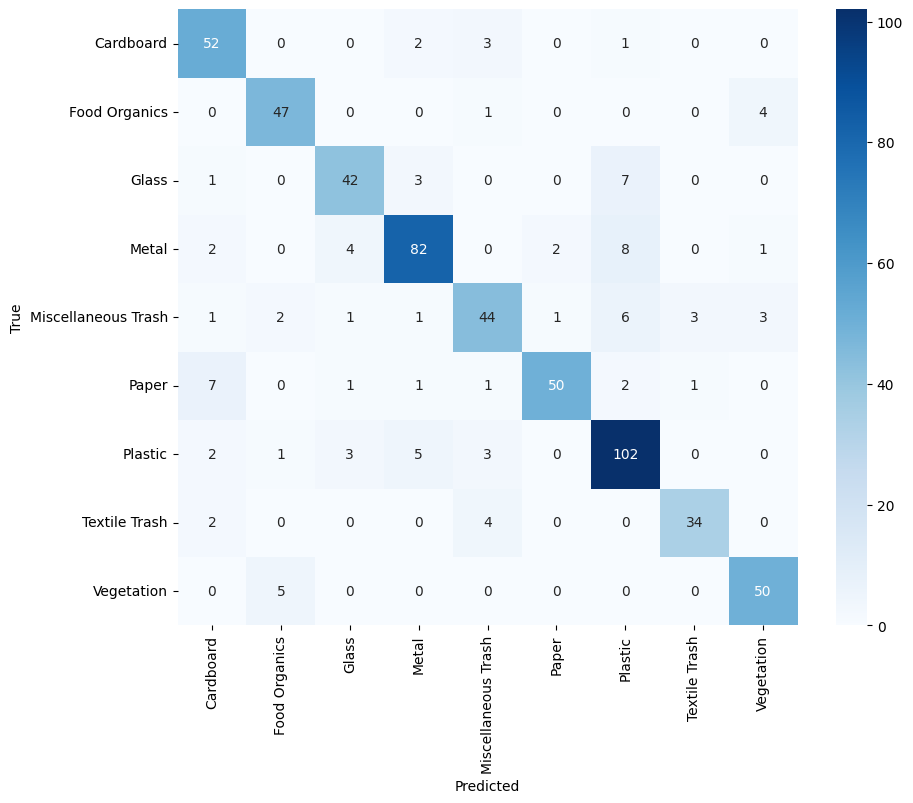

                     precision    recall  f1-score   support

          Cardboard       0.78      0.90      0.83        58
      Food Organics       0.85      0.90      0.88        52
              Glass       0.82      0.79      0.81        53
              Metal       0.87      0.83      0.85        99
Miscellaneous Trash       0.79      0.71      0.75        62
              Paper       0.94      0.79      0.86        63
            Plastic       0.81      0.88      0.84       116
      Textile Trash       0.89      0.85      0.87        40
         Vegetation       0.86      0.91      0.88        55

           accuracy                           0.84       598
          macro avg       0.85      0.84      0.84       598
       weighted avg       0.84      0.84      0.84       598



In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# obtener predicciones
y_pred = model_pre.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)

y_true = test_generator.classes
class_names = list(test_generator.class_indices.keys())

# matriz
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.ylabel("True")
plt.xlabel("Predicted")
plt.show()

print(classification_report(y_true, y_pred_classes, target_names=class_names))

###**8.2. Con EfficientB0**

In [ ]:
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

validation_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

# genera lotes de 20 imágenes de 128x128 RGB con 9 clases (categorical)
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size = (380, 380),
    batch_size = 32,
    class_mode='categorical',
    shuffle=True
)

# hacemos lo mismo para la validación usando test_datagen
validation_generator = validation_datagen.flow_from_directory(
    validation_dir,
    target_size = (380, 380),
    batch_size = 32,
    class_mode='categorical')

test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size = (380, 380),
    batch_size = 32,
    class_mode='categorical',
    shuffle=False
)

Found 3561 images belonging to 9 classes.
Found 593 images belonging to 9 classes.
Found 598 images belonging to 9 classes.


In [ ]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models, optimizers
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense
from tensorflow.keras.preprocessing.image import ImageDataGenerator

num_classes = 9
#Cargamos la base convolucional preentrenada
conv_base_2 = EfficientNetB0(
    weights='imagenet',
    include_top=False,          # quitamos las capas densas originales
    input_shape=(380, 380, 3)
)

#Congelamos la base convulucional
conv_base_2.trainable=False

#Definición del modelo
model_pre2 = models.Sequential([
    conv_base_2,
    layers.GlobalAveragePooling2D(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])

#Compilar
model_pre2.compile(
    optimizer=optimizers.RMSprop(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy', 'precision', 'recall']
)

In [ ]:
#Entrenamiento
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import numpy as np

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True)

lr_reduce = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    verbose=1)


history_pre2 = model_pre2.fit(
    train_generator,
    epochs=30,
    validation_data=validation_generator,
    callbacks=[early_stop, lr_reduce]

)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
112/112 ━━━━━━━━━━━━━━━━━━━━ 64s 396ms/step - accuracy: 0.3371 - loss: 1.8774 - precision: 0.7906 - recall: 0.0317 - val_accuracy: 0.7201 - val_loss: 1.0134 - val_precision: 0.9289 - val_recall: 0.3305 - learning_rate: 1.0000e-04
Epoch 2/30
112/112 ━━━━━━━━━━━━━━━━━━━━ 22s 200ms/step - accuracy: 0.6731 - loss: 1.0495 - precision: 0.8500 - recall: 0.3822 - val_accuracy: 0.7740 - val_loss: 0.6938 - val_precision: 0.8704 - val_recall: 0.6341 - learning_rate: 1.0000e-04
Epoch 3/30
112/112 ━━━━━━━━━━━━━━━━━━━━ 22s 200ms/step - accuracy: 0.7510 - loss: 0.7670 - precision: 0.8593 - recall: 0.6056 - val_accuracy: 0.8145 - val_loss: 0.5719 - val_precision: 0.8743 - val_recall: 0.7504 - learning_rate: 1.0000e-04
Epoch 4/30
112/112 ━━━━━━━━━━━━━━━━━━━━ 22s 199ms/step - accuracy: 0.7691 - loss: 0.6471 - precision: 0.8541 - recall: 0.6887 - val_accuracy: 0.8449 - val_loss: 0.4957 - val_precision: 0.8790 - val_recall: 0.7960 - learning_rate: 1.0000e-04
Epoch 5/30
112/112 ━━━━━━━━━━━━━━━━━

19/19 ━━━━━━━━━━━━━━━━━━━━ 16s 517ms/step


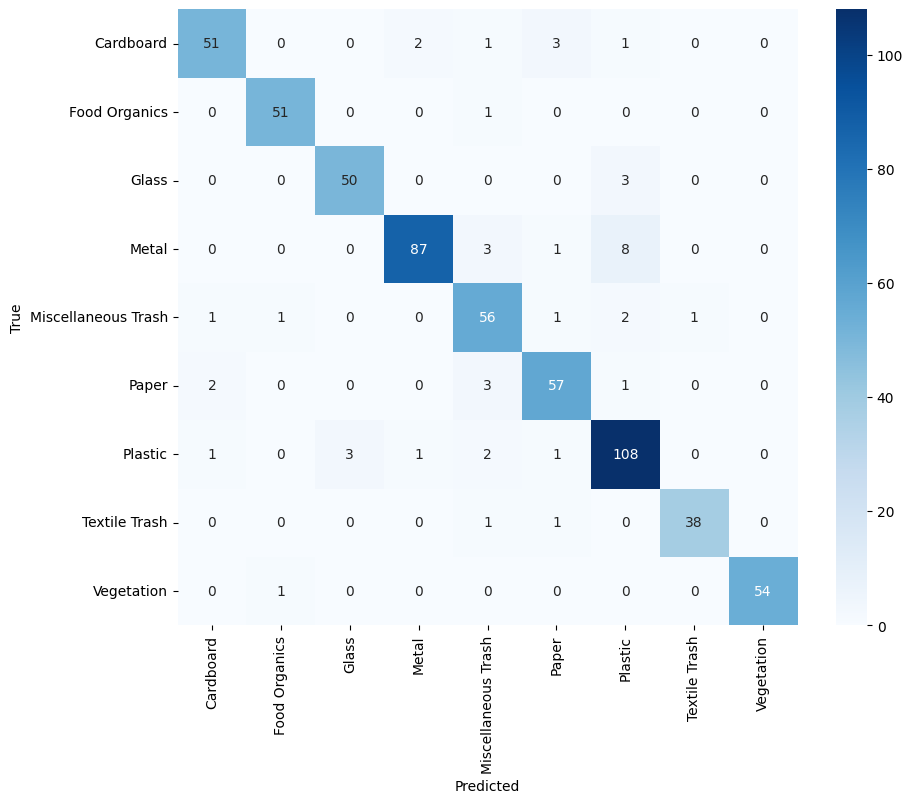

                     precision    recall  f1-score   support

          Cardboard       0.93      0.88      0.90        58
      Food Organics       0.96      0.98      0.97        52
              Glass       0.94      0.94      0.94        53
              Metal       0.97      0.88      0.92        99
Miscellaneous Trash       0.84      0.90      0.87        62
              Paper       0.89      0.90      0.90        63
            Plastic       0.88      0.93      0.90       116
      Textile Trash       0.97      0.95      0.96        40
         Vegetation       1.00      0.98      0.99        55

           accuracy                           0.92       598
          macro avg       0.93      0.93      0.93       598
       weighted avg       0.93      0.92      0.92       598



In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# obtener predicciones
y_pred = model_pre2.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)

y_true = test_generator.classes
class_names = list(test_generator.class_indices.keys())

# matriz
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.ylabel("True")
plt.xlabel("Predicted")
plt.show()

print(classification_report(y_true, y_pred_classes, target_names=class_names))

####**8.2.1. Fine tuning**

In [ ]:
# 1️⃣ Descongelamos las últimas capas de MobileNetV2
conv_base_2.trainable = True

# Solo entrenamos las últimas 30 capas (ajusta según memoria y resultados)
for layer in conv_base_2.layers[:-25]:
    layer.trainable = False

# 2️⃣ Compilamos de nuevo con un learning rate bajo
model_pre2.compile(
    optimizer=optimizers.RMSprop(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy', 'precision', 'recall']
)

# 3️⃣ Callbacks: EarlyStopping y ReduceLROnPlateau
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

lr_reduce = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    verbose=1
)

# 4️⃣ Entrenamiento fine-tuning
history_ft2 = model_pre2.fit(
    train_generator,
    epochs=20,  # menos que entrenamiento inicial
    validation_data=validation_generator,
    callbacks=[early_stop, lr_reduce]
)

Epoch 1/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 71s 416ms/step - accuracy: 0.8930 - loss: 0.3796 - precision: 0.9416 - recall: 0.8294 - val_accuracy: 0.9224 - val_loss: 0.2754 - val_precision: 0.9404 - val_recall: 0.9039 - learning_rate: 1.0000e-05
Epoch 2/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 22s 195ms/step - accuracy: 0.9138 - loss: 0.3068 - precision: 0.9415 - recall: 0.8704 - val_accuracy: 0.9056 - val_loss: 0.3167 - val_precision: 0.9242 - val_recall: 0.8836 - learning_rate: 1.0000e-05
Epoch 3/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 22s 196ms/step - accuracy: 0.9240 - loss: 0.2676 - precision: 0.9509 - recall: 0.8878 - val_accuracy: 0.8988 - val_loss: 0.3271 - val_precision: 0.9257 - val_recall: 0.8820 - learning_rate: 1.0000e-05
Epoch 4/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - accuracy: 0.9260 - loss: 0.2377 - precision: 0.9459 - recall: 0.8946
Epoch 4: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
112/112 ━━━━━━━━━━━━━━━━━━━━ 22s 192ms/step - accuracy: 0.9260 - loss: 0.237

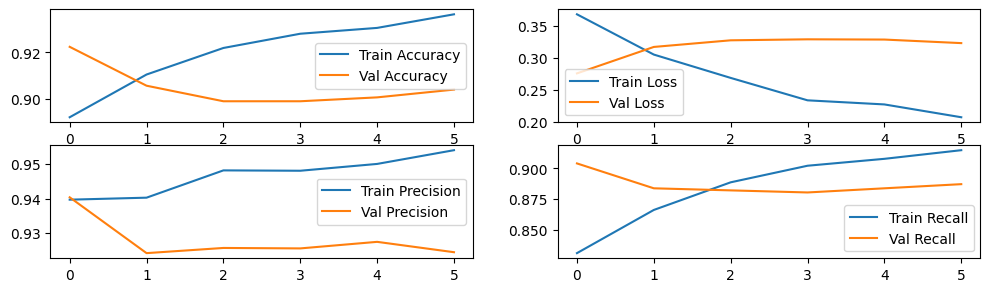

In [ ]:
import matplotlib.pyplot as plt

acc = history_ft2.history['accuracy']
val_acc = history_ft2.history['val_accuracy']
loss = history_ft2.history['loss']
val_loss = history_ft2.history['val_loss']
precision = history_ft2.history['precision']
val_precision = history_ft2.history['val_precision']
recall = history_ft2.history['recall']
val_recall = history_ft2.history['val_recall']

epochs_range = range(len(acc))

plt.figure(figsize=(12,5))

plt.subplot(3,2,1)
plt.plot(epochs_range, acc, label="Train Accuracy")
plt.plot(epochs_range, val_acc, label="Val Accuracy")
plt.legend()

plt.subplot(3,2,2)
plt.plot(epochs_range, loss, label="Train Loss")
plt.plot(epochs_range, val_loss, label="Val Loss")
plt.legend()

plt.subplot(3,2,3)
plt.plot(epochs_range, precision, label="Train Precision")
plt.plot(epochs_range, val_precision, label="Val Precision")
plt.legend()

plt.subplot(3,2,4)
plt.plot(epochs_range, recall, label="Train Recall")
plt.plot(epochs_range, val_recall, label="Val Recall")
plt.legend()

plt.show()

19/19 ━━━━━━━━━━━━━━━━━━━━ 16s 508ms/step


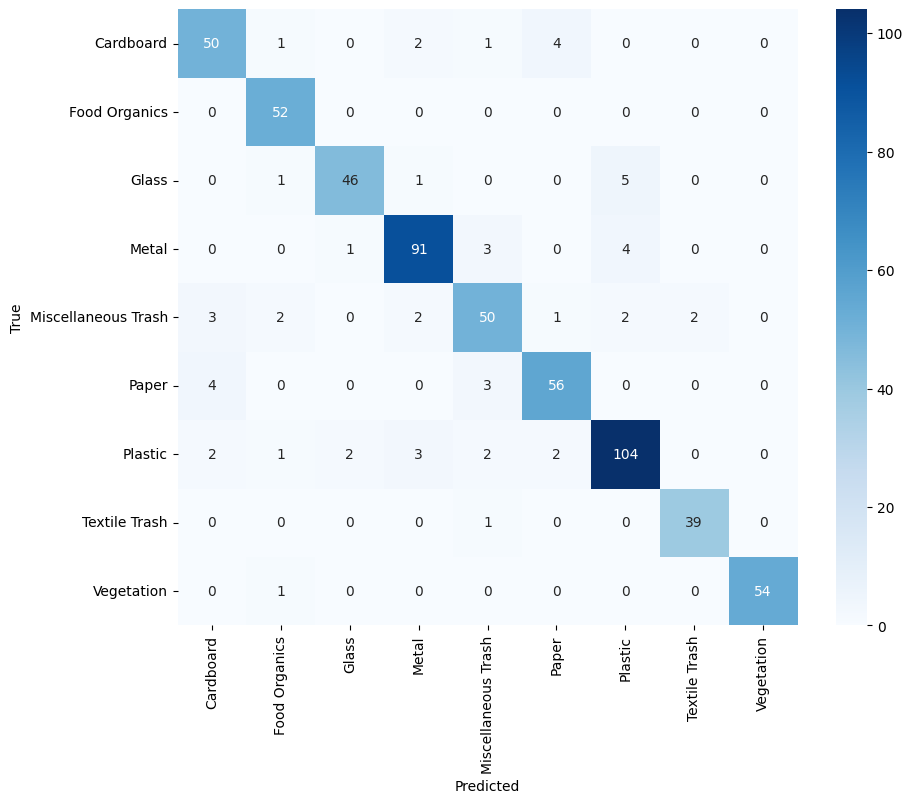

                     precision    recall  f1-score   support

          Cardboard       0.85      0.86      0.85        58
      Food Organics       0.90      1.00      0.95        52
              Glass       0.94      0.87      0.90        53
              Metal       0.92      0.92      0.92        99
Miscellaneous Trash       0.83      0.81      0.82        62
              Paper       0.89      0.89      0.89        63
            Plastic       0.90      0.90      0.90       116
      Textile Trash       0.95      0.97      0.96        40
         Vegetation       1.00      0.98      0.99        55

           accuracy                           0.91       598
          macro avg       0.91      0.91      0.91       598
       weighted avg       0.91      0.91      0.91       598



In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# obtener predicciones
y_pred = model_pre2.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)

y_true = test_generator.classes
class_names = list(test_generator.class_indices.keys())

# matriz
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.ylabel("True")
plt.xlabel("Predicted")
plt.show()

print(classification_report(y_true, y_pred_classes, target_names=class_names))

##*ENFOQUE C - FEATURE EXTRACTOR CON CNN PREENTRENADA + ENTRENAMIENTO ML*

##**9. CNN preentrenadas como Feature Extractor**

La extracción de características consiste en utilizar las representaciones aprendidas por una red anterior para extraer características interesantes de nuevas muestras.

A continuación, estas características se pasan por un nuevo clasificador, que se entrena desde cero, en este caso, será un modelo de ML.

Como se ha visto anteriormente, las redes convolucionales utilizadas para la clasificación de imágenes constan de dos partes: comienzan con una serie de capas de maxpooling y convolución, y terminan con un clasificador densamente conectado.

La primera parte se denomina la base convolucional del modelo. En el caso de las redes convolucionales, la extracción de características consiste en tomar la base convolucional de una red previamente entrenada, pasar los nuevos datos por ella y entrenar un nuevo clasificador sobre la salida.

Al tener un dataset pequeño, usar una CNN preentrenada solo para extraer embeddings (features) y luego entrenador encima un modelo de Machine Learning.

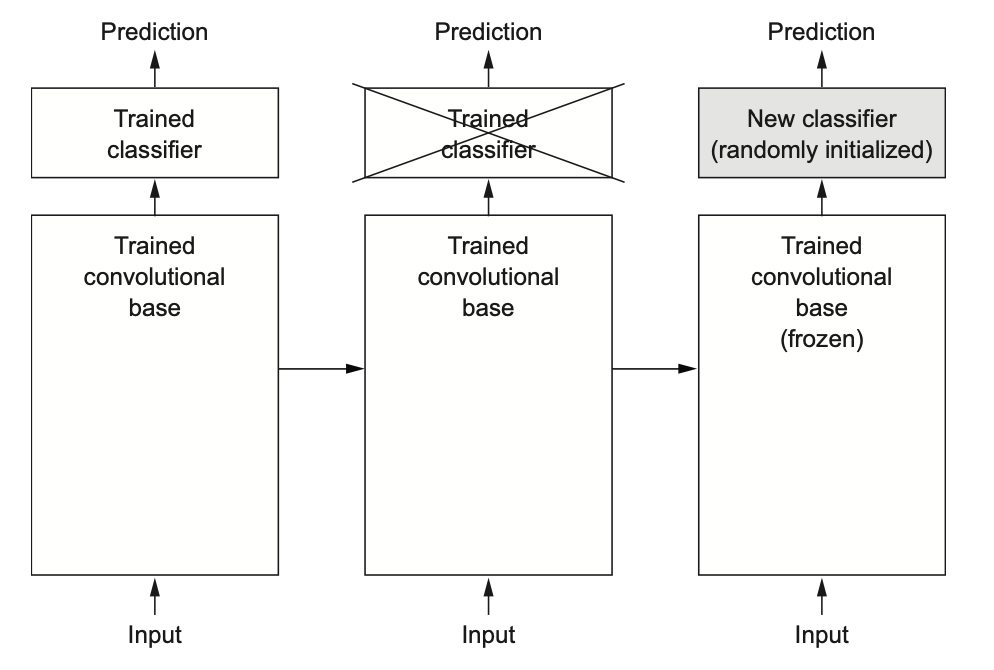

In [ ]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
from tqdm import tqdm

#Modelo preentrenado sin la parte densa
conv_base = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(380, 380, 3),
    pooling="avg"  # → devuelve un vector 1280D para luego ML
)

#Generadores sin aumentation -> solo para features
datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_gen = datagen.flow_from_directory(
    train_dir,
    target_size=(380, 380),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

val_gen = datagen.flow_from_directory(
    validation_dir,
    target_size=(380, 380),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

test_gen = datagen.flow_from_directory(
    test_dir,
    target_size=(380, 380),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 3561 images belonging to 9 classes.
Found 593 images belonging to 9 classes.
Found 598 images belonging to 9 classes.


A continuación, creamos la función 'extract_features_from_generator' que recibirá uno de los generadores de imágenes creados anteriormente (train_gen, val_gen o test_gen), que entrega lotes (batches) de imágenes y etiquetas.

La función recorre todo el generador, pasa las imágenes por el modelo convolucional y guarda:
- Las características extraídas (features)
- Las etiquetas (en formato entero)

Devuelve dos matrices: features y labels.

In [ ]:
#Función para feature extraction: recibe generator (generador de imágenes) y el modelo conv preentrenado
def extract_features_from_generator(generator, conv_base):
  #Extraer num_samples y batch_size de generator
  num_samples = generator.samples #nº de imágenes en total
  batch_size = generator.batch_size #tamaño del batch

  #Creación de las matrices vacías features and labels
  features = np.zeros((num_samples, 1280), dtype='float32')   #Como hemos puesto pooling='avg' tengo vector 1280
  labels = np.zeros((num_samples,), dtype='int')

  #Generamos características
  i=0
  #Recorremos el generador
  for images_batch, labels_batch in tqdm(generator):
  # Usamos el predict de la conv_base para obtener las características para cada imagen del batch
    features_batch = conv_base.predict(images_batch, verbose=0)
    #Guardamos
    batch_start = i*batch_size
    batch_end = min(batch_start + features_batch.shape[0], num_samples)

    # obtenemos las features
    features[batch_start:batch_end] = features_batch[:batch_end - batch_start]
    # obtenemos sus etiquetas, conversión a clase entera
    labels[batch_start:batch_end] = np.argmax(labels_batch[:batch_end - batch_start], axis=1)

    i += 1
    #Debemos poner un break para que no se ejecute eternamente
    if batch_end >= num_samples:
      break
  return features, labels

In [ ]:
X_train, y_train = extract_features_from_generator(train_gen, conv_base)
X_val, y_val = extract_features_from_generator(val_gen, conv_base)
X_test, y_test = extract_features_from_generator(test_gen, conv_base)



 95%|█████████▍| 18/19 [00:11<00:00,  1.51it/s]


In [ ]:
print("Features extraídas:")
print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Features extraídas:
Train: (3561, 1280) (3561,)
Validation: (593, 1280) (593,)
Test: (598, 1280) (598,)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)


##**10. Entrenamiento ML**

###**10.1. Random Forest**

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

rf = RandomForestClassifier(
    n_estimators=1000,
    max_depth=None,
    class_weight="balanced",
    min_samples_split=2,
    random_state=42
)

rf.fit(X_train, y_train)

# Evaluación
print("\n📌 RANDOM FOREST - VALIDATION REPORT")
y_pred_val = rf.predict(X_val)
print(classification_report(y_val, y_pred_val))

print("\n📌 RANDOM FOREST - TEST REPORT")
y_pred_test = rf.predict(X_test)
print(classification_report(y_test, y_pred_test))



📌 RANDOM FOREST - VALIDATION REPORT
              precision    recall  f1-score   support

           0       0.82      0.86      0.84        58
           1       0.84      0.96      0.90        51
           2       1.00      0.83      0.91        52
           3       0.88      0.92      0.90        99
           4       0.85      0.66      0.75        62
           5       0.87      0.89      0.88        62
           6       0.82      0.90      0.86       115
           7       0.92      0.90      0.91        40
           8       0.96      0.91      0.93        54

    accuracy                           0.87       593
   macro avg       0.89      0.87      0.88       593
weighted avg       0.88      0.87      0.87       593


📌 RANDOM FOREST - TEST REPORT
              precision    recall  f1-score   support

           0       0.87      0.79      0.83        58
           1       0.85      0.90      0.88        52
           2       0.98      0.87      0.92        53
          

###**10.2. XGBoost Classifier**

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

xgb = XGBClassifier(
    n_estimators=800,
    learning_rate=0.05,
    max_depth=9,
    objective="multi:softmax",
    num_class=9,
    random_state=42
)

xgb.fit(X_train_scaled, y_train)

# Evaluación
print("\n📌 XGBOOST - VALIDATION REPORT")
y_pred_val = xgb.predict(X_val_scaled)
print(classification_report(y_val, y_pred_val))

print("\n📌 XGBOOST - TEST REPORT")
y_pred_test = xgb.predict(X_test_scaled)
print(classification_report(y_test, y_pred_test))



📌 XGBOOST - VALIDATION REPORT
              precision    recall  f1-score   support

           0       0.91      0.88      0.89        58
           1       0.89      0.92      0.90        51
           2       0.95      0.81      0.88        52
           3       0.88      0.90      0.89        99
           4       0.79      0.74      0.77        62
           5       0.90      0.89      0.89        62
           6       0.82      0.88      0.85       115
           7       0.88      0.88      0.88        40
           8       0.89      0.94      0.92        54

    accuracy                           0.87       593
   macro avg       0.88      0.87      0.87       593
weighted avg       0.87      0.87      0.87       593


📌 XGBOOST - TEST REPORT
              precision    recall  f1-score   support

           0       0.83      0.83      0.83        58
           1       0.91      0.92      0.91        52
           2       0.87      0.87      0.87        53
           3       0.9

###**10.3. LGBM Classifier**

In [ ]:
import lightgbm as lgb
from sklearn.metrics import classification_report

lgb_model = lgb.LGBMClassifier(
    num_leaves=64,
    learning_rate=0.05,
    n_estimators=800,
    objective='multiclass',
    max_depth=-1,
    num_class=9
)

lgb_model.fit(X_train, y_train)

y_pred = lgb_model.predict(X_test)
print(classification_report(y_test, y_pred))


Se han truncado las últimas 5000 líneas del flujo de salida.
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits 

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


###**10.4. SVC Classifier**

In [ ]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report
from sklearn.preprocessing import MinMaxScaler


svm = Pipeline([
    #("scaler", StandardScaler()),
    ("scaler", MinMaxScaler()),
    ("svm", SVC(kernel="rbf", C=10, gamma="scale"))

])

svm.fit(X_train, y_train)

# Evaluación
print("\n📌 SVM - VALIDATION REPORT")
y_pred_val = svm.predict(X_val)
print(classification_report(y_val, y_pred_val))


print("\n📌 SVM - TEST REPORT")
y_pred_test = svm.predict(X_test)
print(classification_report(y_test, y_pred_test))



📌 SVM - VALIDATION REPORT
              precision    recall  f1-score   support

           0       0.90      0.93      0.92        58
           1       0.94      0.98      0.96        51
           2       0.94      0.90      0.92        52
           3       0.91      0.97      0.94        99
           4       0.89      0.82      0.86        62
           5       0.92      0.95      0.94        62
           6       0.91      0.89      0.90       115
           7       0.95      0.93      0.94        40
           8       0.98      0.96      0.97        54

    accuracy                           0.92       593
   macro avg       0.93      0.93      0.93       593
weighted avg       0.92      0.92      0.92       593


📌 SVM - TEST REPORT
              precision    recall  f1-score   support

           0       0.96      0.91      0.94        58
           1       1.00      0.96      0.98        52
           2       0.96      0.91      0.93        53
           3       0.86      0

In [ ]:
import joblib
joblib.dump(svm, "best_norm&model_svm.pkl")


['best_norm&model_svm.pkl']

In [ ]:
train_pred = svm.predict(X_train)

from sklearn.metrics import accuracy_score

print("Train accuracy:", accuracy_score(y_train, train_pred))
print("Test accuracy:", accuracy_score(y_test, y_pred_test))


Train accuracy: 1.0
Test accuracy: 0.9264214046822743


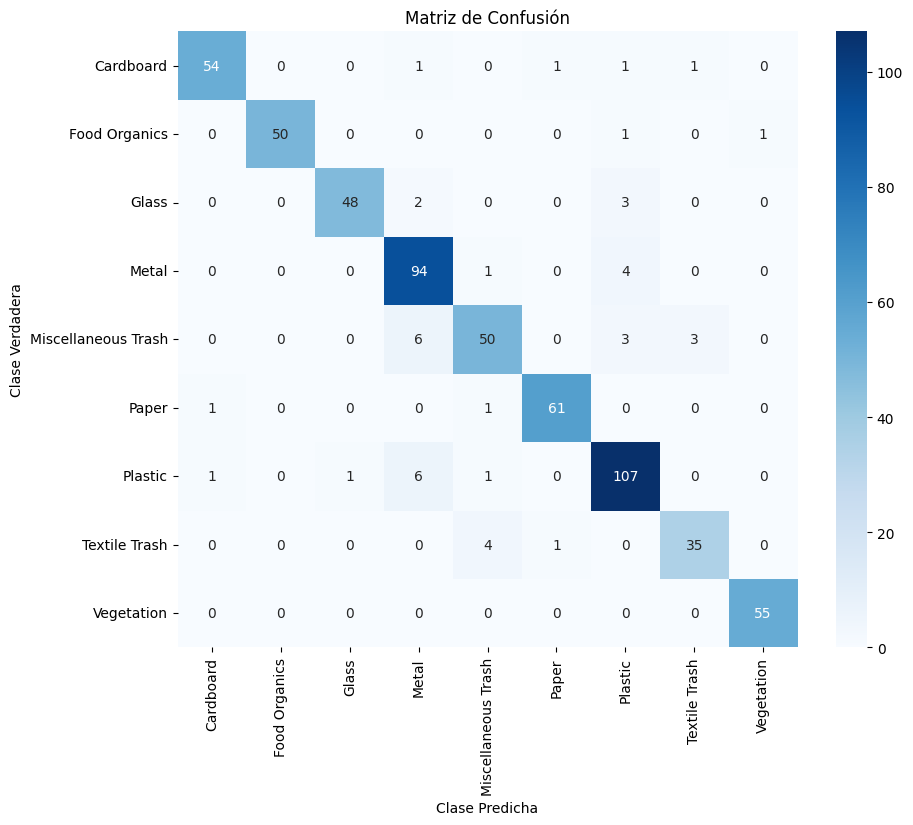

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

class_names = ["Cardboard", "Food Organics", "Glass", "Metal",
               "Miscellaneous Trash", "Paper", "Plastic", "Textile Trash", "Vegetation"]

# Calculamos la matriz de confusión
cm = confusion_matrix(y_test, y_pred_test)

# Visualizamos con un heatmap
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Clase Predicha")
plt.ylabel("Clase Verdadera")
plt.title("Matriz de Confusión")
plt.show()

#####**10.4.1. Optimización SVC**

In [ ]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report

# 1️⃣ Definimos el pipeline: escalado + SVM
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC())
])

# 2️⃣ Definimos el grid de hiperparámetros
param_grid = {
    "svm__C": [0.1, 1, 10, 50],
    "svm__gamma": ["scale", 0.01, 0.001, "auto"],
    "svm__kernel": ["rbf", "poly", "sigmoid"],
    "svm__class_weight": [None]
}

# 3️⃣ GridSearchCV
grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,               # 5-fold cross-validation
    scoring="f1_macro", # podemos priorizar f1_macro si nos interesa balance entre clases
    verbose=2,
    n_jobs=-1
)

# 4️⃣ Entrenamos en los features extraídos
grid.fit(X_train, y_train)

# 5️⃣ Mejor combinación de hiperparámetros
print("Mejores hiperparámetros:", grid.best_params_)

# 6️⃣ Evaluamos en validación o test
y_pred = grid.predict(X_test)
print(classification_report(y_test, y_pred))


Fitting 5 folds for each of 48 candidates, totalling 240 fits
Mejores hiperparámetros: {'svm__C': 10, 'svm__class_weight': None, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}
              precision    recall  f1-score   support

           0       0.89      0.88      0.89        58
           1       0.94      0.98      0.96        52
           2       0.96      0.96      0.96        53
           3       0.93      0.94      0.93        99
           4       0.90      0.90      0.90        62
           5       0.88      0.92      0.90        63
           6       0.95      0.91      0.93       116
           7       0.98      1.00      0.99        40
           8       1.00      0.96      0.98        55

    accuracy                           0.93       598
   macro avg       0.94      0.94      0.94       598
weighted avg       0.94      0.93      0.93       598



##**11. Comprobación real con imágenes**

In [ ]:
import numpy as np
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.preprocessing import image
import cv2
from PIL import Image
# ---------------------------------------------
# Modelo preentrenado
# ---------------------------------------------
conv_base = EfficientNetB0(
        weights="imagenet",
        include_top=False,
        pooling="avg",
        input_shape=(380, 380, 3))

# ---------------------------------------------
# Preprocess and extract features from a image
# ---------------------------------------------
def extract_features_from_image(img, conv_base):

    # Redimensionar a 380x380
    img_resized = cv2.resize(img, (380, 380))

    # Convertir a float32 y expandir dimensiones
    img_array = img_resized.astype(np.float32)
    img_array = np.expand_dims(img_array, axis=0)

    # Preprocess (EfficientNet)
    img_array = preprocess_input(img_array)

    # Extract features
    features = conv_base.predict(img_array, verbose=0)
    return features

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
from joblib import load
model = load("best_norm&model_svm.pkl")

image = cv2.imread("plastic4.jpeg")
features = extract_features_from_image(image, conv_base)
y_pred = model.predict(features)

In [ ]:
CLASS_NAMES = [
    "Cardboard", "Food Organics", "Glass", "Metal", "Misc Trash",
    "Paper", "Plastic", "Textile Trash", "Vegetation"]

In [ ]:
print(CLASS_NAMES[y_pred[0]])

Metal


##**12. Conclusiones**

- **Enfoque híbrido Machine Learning y Deep Learning.** Al tener un dataset pequeño, la red neuronal CNN preentrenada funciona mejor como *Feature Extractor* y el entrenamiento es mejor con modelos clásicos Machine Learning.
- **Buen rendimiento y bajo coste computacional.** El entrenamiento con el modelo SVM es rápido y no presenta un coste computacional elevado pudiendo obtener las predicciones rápidas.
- **Solución escalable y adaptable a nuevas clases.** Añadir nuevas clases y realizar la extracción de características sería posible y seguiriamos el mismo procedimiento.
- **Optimización del proceso industrial actual.** Aumento de la productividad en la gestión de residuos.

##**13. Mejoras futuras**

- **Ampliación del dataset.** Aumento de la variabilidad en las imágenes y la cantidad de datos presentaría mejoras sobretodo en la parte de entrenamiento de modelos Deep Learning.
- **Escalabilidad industrial.** Se podrían añadir la clasificación de nuevas clases escalando la aplicación a otros sectores, por ejemplo, chips electrónicos.
- **Optimización en el *Feature Extractor*.** Mejorar la parte de extracción de características podría mejorar las métricas obtenidas posteriormente en el entrenamiento de modelos clásicos Machine Learning.
